In [1]:
# 1
# This cell cleans artist and track names (fixes encoding issues, removes corrupted/invalid text).
# Then it removes bad or unknown rows and saves the cleaned and removed data into separate CSV files.

import pandas as pd
import re
import unicodedata

IN_PATH  = "/content/users_tracks.csv"
OUT_CLEAN = "/content/users_tracks_cleaned.csv"
OUT_REMOVED = "/content/users_tracks_removed_rows.csv"

# ---- CONFIG ----
ARTIST_COL = "artist_name"
TRACK_COL  = "track_name"

# Treat these as unknown artists (case-insensitive)
UNKNOWN_ARTISTS = {
    "unknown", "[unknown]", "various artists", "n/a", "na", "none", "null", ""
}

# ---- Helpers ----

def contains_hebrew(s: str) -> bool:
    if not s:
        return False
    return bool(re.search(r"[\u0590-\u05FF]", s))

def normalize_whitespace(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def looks_like_mojibake(s: str) -> bool:
    # Common mojibake sequences from bad UTF-8/Windows-1252 mixing
    patterns = ["Ã", "Â", "â€", "â€™", "â€œ", "â€\x9d", "Ð", "Ñ", "Ø", "�"]
    return any(p in s for p in patterns)

def try_fix_mojibake(s: str) -> str:
    """
    Attempt best-effort repair of mojibake.
    Tries latin1->utf8 and cp1252->utf8 re-decodes.
    If it fails, returns original.
    """
    if not s or not looks_like_mojibake(s):
        return s

    candidates = [s]
    for enc in ("latin1", "cp1252"):
        try:
            candidates.append(s.encode(enc, errors="ignore").decode("utf-8", errors="ignore"))
        except Exception:
            pass

    # Choose the candidate with:
    # - fewest replacement chars
    # - most letters (any script)
    def score(x: str):
        repl = x.count("�")
        letters = sum(ch.isalpha() for ch in x)
        return (repl, -letters, len(x))  # lower is better

    best = min(candidates, key=score)
    return best

def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)

    # fix mojibake if detected
    s = try_fix_mojibake(s)

    # normalize unicode (combining marks, etc.)
    s = unicodedata.normalize("NFKC", s)

    # remove control chars (but keep normal punctuation)
    s = "".join(ch for ch in s if unicodedata.category(ch)[0] != "C" or ch in "\t\n\r")
    s = normalize_whitespace(s)

    return s

def is_unknown_artist(s: str) -> bool:
    x = normalize_whitespace((s or "")).lower()
    return x in UNKNOWN_ARTISTS

def gibberish_ratio(s: str) -> float:
    """
    Estimate corruption:
    - replacement chars
    - too many non-letter/digit/punct spaces
    """
    if not s:
        return 1.0
    total = len(s)

    replacement = s.count("�")
    # count "bad" chars: not letter, not digit, not common punctuation/space
    bad = 0
    for ch in s:
        if ch.isalpha() or ch.isdigit() or ch.isspace():
            continue
        # allow common punctuation
        if ch in "-–—'’\"“”.,:;!?()[]&+/":
            continue
        # allow diacritics already handled by isalpha
        bad += 1

    return (replacement + bad) / max(total, 1)

def too_corrupted(s: str) -> bool:
    """
    Rules tuned for your screenshots:
    - lots of replacement chars or weird symbol density
    - too few alphabetic letters (e.g., mostly symbols)
    """
    if not s:
        return True

    # if many replacement chars, likely broken
    if s.count("�") >= 2:
        return True

    # if high gibberish ratio
    if gibberish_ratio(s) > 0.35:
        return True

    # require some letters (support non-latin scripts too)
    letters = sum(ch.isalpha() for ch in s)
    if letters < 2:
        return True

    # extremely long but low letters (garbage blocks)
    if len(s) > 40 and letters / len(s) < 0.2:
        return True

    return False

# ---- Load ----
df = pd.read_csv(IN_PATH)

for col in [ARTIST_COL, TRACK_COL]:
    if col not in df.columns:
        raise ValueError(f"Missing column '{col}' in users_tracks.csv. Found: {df.columns.tolist()}")

# ---- Clean text columns ----
df[ARTIST_COL] = df[ARTIST_COL].apply(clean_text)
df[TRACK_COL]  = df[TRACK_COL].apply(clean_text)

mask_unknown = df[ARTIST_COL].apply(is_unknown_artist)

mask_bad_artist = (
    df[ARTIST_COL].apply(too_corrupted) |
    df[ARTIST_COL].apply(contains_hebrew)
)

mask_bad_track = (
    df[TRACK_COL].apply(too_corrupted) |
    df[TRACK_COL].apply(contains_hebrew)
)

# Remove if:
# - unknown artist
# - artist corrupted OR contains Hebrew
# - track corrupted OR contains Hebrew
remove_mask = mask_unknown | mask_bad_artist | mask_bad_track

removed = df[remove_mask].copy()
cleaned = df[~remove_mask].copy()

# ---- Save ----
cleaned.to_csv(OUT_CLEAN, index=False)
removed.to_csv(OUT_REMOVED, index=False)

print("Original rows:", len(df))
print("Cleaned rows :", len(cleaned))
print("Removed rows :", len(removed))
print("Saved cleaned ->", OUT_CLEAN)
print("Saved removed ->", OUT_REMOVED)

# Quick peek at removed examples
print("\nExamples removed (artist, track):")
print(removed[[ARTIST_COL, TRACK_COL]].head(20))


Original rows: 222634
Cleaned rows : 222634
Removed rows : 0
Saved cleaned -> /content/users_tracks_cleaned.csv
Saved removed -> /content/users_tracks_removed_rows.csv

Examples removed (artist, track):
Empty DataFrame
Columns: [artist_name, track_name]
Index: []


In [2]:
# 2
# It installs required libraries, loads the dataset, and cleans whitespace in the artist and track columns.
# Then it creates a list of unique artist–track pairs to avoid duplicate API enrichment call

!pip -q install musicbrainzngs rapidfuzz requests tqdm

import pandas as pd

df = pd.read_csv("/content/users_tracks.csv")  # adjust path if needed
df["artist_name"] = df["artist_name"].astype(str).str.strip()
df["track_name"]  = df["track_name"].astype(str).str.strip()

# Unique artist-track pairs to enrich (saves lots of API calls)
pairs = df[["artist_name","track_name"]].drop_duplicates().reset_index(drop=True)
pairs.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.9 MB/s eta 0:00:00


,artist_name,track_name
0,Deep Dish,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,Underworld,"Boy, Boy, Boy (Switch Remix)"
2,Underworld,Crocodile (Innervisions Orchestra Mix)
3,Ennio Morricone,Ninna Nanna In Blu (Raw Deal Remix)
4,Minus 8,Elysian Fields


In [4]:
# 3
# This code loads a dataset and finds rows where origin_country is missing.
# It queries the MusicBrainz API for each unique missing artist to get their country, fills the missing values, and saves the updated dataset.


import pandas as pd
import musicbrainzngs as mb
from tqdm import tqdm
import time

IN_PATH  = "/content/test_pool_500_year.csv"
OUT_PATH = "/content/test_pool_500_year_country.csv"

df = pd.read_csv(IN_PATH)

# Clean strings
df["artist_name"] = df["artist_name"].astype(str).str.strip()
df["track_name"]  = df["track_name"].astype(str).str.strip()

# Make sure the column exists
if "origin_country" not in df.columns:
    df["origin_country"] = pd.NA

# ----------------------------
# Only rows with missing country
# ----------------------------
missing = df[df["origin_country"].isna() & df["artist_name"].notna()].copy()
print("Rows missing origin_country:", len(missing))

# For country, we only need unique ARTISTS
missing_artists = sorted(missing["artist_name"].dropna().unique())
print("Unique artists to query:", len(missing_artists))

mb.set_useragent("UniProjectMetadataEnrichment", "1.0", "your_email@example.com")

def mb_artist_country(artist_name):
    """
    Try top few search results and return the first country we find.
    Using limit>1 helps when the top hit has no country.
    """
    try:
        res = mb.search_artists(artist=artist_name, limit=5)
        artists = res.get("artist-list", [])
        for a in artists[:5]:
            c = a.get("country")
            if c:
                return c
    except Exception:
        return None
    return None

# ----------------------------
# Query only missing artists (with cache)
# ----------------------------
artist_to_country = {}

for artist in tqdm(missing_artists):
    if artist in artist_to_country:
        continue
    artist_to_country[artist] = mb_artist_country(artist)
    time.sleep(1.0)

# ----------------------------
# Fill back into df
# ----------------------------
mask = df["origin_country"].isna()
df.loc[mask, "origin_country"] = df.loc[mask, "artist_name"].map(artist_to_country)

# Save
df.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)
print("Country coverage after fill:", df["origin_country"].notna().mean())
df.head()


Rows missing origin_country: 500
Unique artists to query: 450


100%|██████████| 450/450 [12:16<00:00,  1.64s/it]

Saved: /content/test_pool_500_year_country.csv
Country coverage after fill: 0.968


,artist_name,track_name,release_year,origin_country
0,Cubismo Grafico,Aveg Gill (Outro),1999.0,JP
1,Carla Bozulich,Pissing,2006.0,US
2,Andrew Bird,Banking On A Myth,NaN,US
3,Foo Fighters,Let It Die,2011.0,US
4,David Carretta,Kill Your Radio,2005.0,DE


In [5]:
# 4
# This code converts ISO-2 country codes in origin_country into full country names using pycountry.
# It adds the full names as a new column and saves the updated dataset.

!pip -q install pycountry
import pandas as pd
import pycountry

# Load your dataset
INPUT_CSV  = "/content/test_pool_500_year_country.csv"
OUTPUT_CSV = "/content/test_pool_500.csv"

df = pd.read_csv(INPUT_CSV)

def iso2_to_country_name(code):
    if pd.isna(code):
        return None
    code = str(code).strip().upper()
    try:
        country = pycountry.countries.get(alpha_2=code)
        return country.name if country else None
    except Exception:
        return None

# Apply conversion
df["origin_country_full"] = df["origin_country"].apply(iso2_to_country_name)

# df["origin_country"] = df["origin_country_full"]
# df = df.drop(columns=["origin_country_full"])

# Save
df.to_csv(OUTPUT_CSV, index=False)

print("Saved to:", OUTPUT_CSV)
df[["origin_country", "origin_country_full"]].drop_duplicates().head(10)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 90.1 MB/s eta 0:00:00
Saved to: /content/test_pool_500.csv


,origin_country,origin_country_full
0,JP,Japan
1,US,United States
4,DE,Germany
8,GB,United Kingdom
17,NO,Norway
26,NaN,None
28,ES,Spain
38,CA,Canada
62,SE,Sweden
63,FR,France


In [ ]:
# 5
# This script enriches the dataset with a release_year for each (artist, track) pair by first checking a saved cache,
# then extracting a year from the track text if present, and finally querying MusicBrainz (politely rate-limited) when needed.
# It processes only unique artist–track pairs to reduce API calls, saves/updates the cache as it goes,
# merges the found years back into the full dataframe, and writes the final CSV.

import pandas as pd
import numpy as np
import re
import time
import os
!pip -q install musicbrainzngs tqdm

import musicbrainzngs as mb

# =========================
# 0) SETTINGS
# =========================
INPUT_PATH = "/content/test_pool_500.csv"
OUTPUT_PATH = "/content/test_pool_500_year.csv"
CACHE_PATH = "/content/train_year_cache.csv"

# MusicBrainz:
mb.set_useragent("UniProjectMetadataEnrichment", "1.0", "my_email@example.com")

# =========================
# 1) LOAD DATA
# =========================
df = pd.read_csv(INPUT_PATH)


# Required: artist_name, track_name
assert "artist_name" in df.columns and "track_name" in df.columns, df.columns

# =========================
# 2) BASIC STRING HELPERS
# =========================
def clean_text(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_track_for_search(t: str) -> str:
    """Remove common noise that breaks MusicBrainz search."""
    t = clean_text(t)

    # Remove trailing dates like -09-28-2007 or _2009_4_15 or (Live_2009_4_15)
    t = re.sub(r"[-_/]\d{2}[-_/]\d{2}[-_/](19|20)\d{2}$", "", t)
    t = re.sub(r"[-_/](19|20)\d{2}[-_/]\d{1,2}[-_/]\d{1,2}$", "", t)
    t = re.sub(r"[-_/](19|20)\d{2}$", "", t)

    # Remove parenthesis/brackets content (often "Remix", "Live", "Edit", etc.)
    t = re.sub(r"\(.*?\)", "", t)
    t = re.sub(r"\[.*?\]", "", t)

    # Remove extra punctuation repeats
    t = re.sub(r"\s+", " ", t).strip()
    return t

def year_from_text(track_name: str) -> int | None:
    """Cheap heuristic: if track string contains a year, use it."""
    t = clean_text(track_name)
    m = re.search(r"(19|20)\d{2}", t)
    if not m:
        return None
    y = int(m.group())
    # sanity (avoid weird matches)
    if 1900 <= y <= 2026:
        return y
    return None

# =========================
# 3) LOAD / INIT CACHE
# =========================
# Cache keyed by (artist_lower, track_lower)
cache = {}

if os.path.exists(CACHE_PATH):
    cdf = pd.read_csv(CACHE_PATH)
    for _, r in cdf.iterrows():
        cache[(r["artist_key"], r["track_key"])] = None if pd.isna(r["release_year"]) else int(r["release_year"])
    print("Loaded cache entries:", len(cache))

def save_cache():
    out = pd.DataFrame([
        {"artist_key": k[0], "track_key": k[1], "release_year": v}
        for k, v in cache.items()
    ])
    out.to_csv(CACHE_PATH, index=False)

# =========================
# 4) MUSICBRAINZ LOOKUP (more robust)
# =========================
def mb_release_year(artist_name: str, track_name: str) -> int | None:
    artist = clean_text(artist_name)
    track_raw = clean_text(track_name)
    track = normalize_track_for_search(track_raw)

    if not artist or not track:
        return None

    try:

        res = mb.search_recordings(recording=track, artist=artist, limit=5)
        recs = res.get("recording-list", [])
        if not recs:
            return None

        # Try multiple top candidates
        for cand in recs[:5]:
            rec_id = cand.get("id")
            if not rec_id:
                continue

            rec = mb.get_recording_by_id(rec_id, includes=["releases"])
            releases = rec.get("recording", {}).get("release-list", [])
            years = []
            for rel in releases:
                date = rel.get("date")
                if date and len(date) >= 4 and date[:4].isdigit():
                    y = int(date[:4])
                    if 1900 <= y <= 2026:
                        years.append(y)

            if years:
                return min(years)

        return None

    except Exception:
        return None

# =========================
# 5) WORK ON UNIQUE PAIRS ONLY
# =========================
unique_pairs = df[["artist_name", "track_name"]].drop_duplicates().copy()
print("Rows in df:", len(df))
print("Unique (artist, track):", len(unique_pairs))

years_found = []

start = time.time()
for i, row in enumerate(unique_pairs.itertuples(index=False), start=1):
    a = row.artist_name
    t = row.track_name

    a_key = clean_text(a).lower()
    t_key = clean_text(t).lower()
    key = (a_key, t_key)

    # 1) cache
    if key in cache:
        years_found.append(cache[key])
        continue

    # 2) heuristic from text
    y = year_from_text(t)
    if y is not None:
        cache[key] = y
        years_found.append(y)
        continue

    # 3) MusicBrainz
    y = mb_release_year(a, t)
    cache[key] = y
    years_found.append(y)


    time.sleep(1.0)

    # periodic save + ETA
    if i % 100 == 0:
        save_cache()
        elapsed = time.time() - start
        avg = elapsed / i
        remaining = avg * (len(unique_pairs) - i)
        print(f"[{i}/{len(unique_pairs)}] avg {avg:.2f}s/row | ETA ~{remaining/3600:.2f} hours | cache={len(cache)}")

unique_pairs["release_year"] = years_found
save_cache()

# =========================
# 6) MERGE BACK + SAVE
# =========================
df_out = df.merge(unique_pairs, on=["artist_name", "track_name"], how="left")
df_out.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Release year coverage:", df_out["release_year"].notna().mean())
df_out.head()


Loaded cache entries: 1000
Rows in df: 500
Unique (artist, track): 500
[100/500] avg 3.91s/row | ETA ~0.43 hours | cache=1100
[200/500] avg 3.75s/row | ETA ~0.31 hours | cache=1200
[300/500] avg 3.69s/row | ETA ~0.21 hours | cache=1300
[400/500] avg 3.68s/row | ETA ~0.10 hours | cache=1400
[500/500] avg 3.72s/row | ETA ~0.00 hours | cache=1500
Saved: /content/test_pool_500_year.csv
Release year coverage: 0.992


,artist_name,track_name,release_year
0,Cubismo Grafico,Aveg Gill (Outro),1999.0
1,Carla Bozulich,Pissing,2006.0
2,Andrew Bird,Banking On A Myth,NaN
3,Foo Fighters,Let It Die,2011.0
4,David Carretta,Kill Your Radio,2005.0


In [ ]:
# 6
# It loads the top-15 tracks file and the enriched metadata file, then chooses merge keys
# (track_id if available, otherwise artist_name + track_name) and strips whitespace to avoid mismatches.
# Finally, it left-joins the metadata onto the top-15 tracks, saves the merged result to a new CSV, and prints a quick preview.

import pandas as pd

# -------------------------
# PATHS (change if needed)
# -------------------------
TOP15_PATH   = "/content/50_users_tracks_top15.csv"
ENRICHED_PATH = "/content/pairs_enriched.csv"   # contains country, genres, etc.
OUT_PATH     = "/content/50_users_tracks_top15_enriched.csv"

# -------------------------
# LOAD DATA
# -----------
--------------
top15 = pd.read_csv(TOP15_PATH)
enriched = pd.read_csv(ENRICHED_PATH)

print("Top-15 shape:", top15.shape)
print("Enriched shape:", enriched.shape)

# -------------------------
# DECIDE MERGE KEYS
# -------------------------
if "track_id" in top15.columns and "track_id" in enriched.columns:
    merge_cols = ["track_id"]
    print("Merging on track_id")
else:
    merge_cols = ["artist_name", "track_name"]
    print("Merging on artist_name + track_name")

# -------------------------
# CLEAN STRINGS (important!)
# -------------------------
for c in merge_cols:
    top15[c] = top15[c].astype(str).str.strip()
    enriched[c] = enriched[c].astype(str).str.strip()

# -------------------------
# MERGE
# -------------------------
merged = top15.merge(
    enriched,
    on=merge_cols,
    how="left",
    suffixes=("", "_meta")
)

# -------------------------
# SAVE
# -------------------------
merged.to_csv(OUT_PATH, index=False)

print("Merged shape:", merged.shape)
print("Saved to:", OUT_PATH)

merged.head()


Top-15 shape: (3000, 9)
Enriched shape: (4602, 4)
Merging on artist_name + track_name
Merged shape: (3000, 11)
Saved to: /content/50_users_tracks_top15_enriched.csv


,user_id,artist_name,track_name,track_play_count,artist_play_count,time_window_days,window_start,window_end,release_year,origin_country,release_year_meta
0,user_000001,Scsi-9,"Vesna, Lastic & Elliott",17,138,30,2009-01-01T00:00:00+00:00,2009-01-31T00:00:00+00:00,2013.0,NaN,NaN
1,user_000001,Plaid,Bata,7,109,30,2009-01-01T00:00:00+00:00,2009-01-31T00:00:00+00:00,2008.0,GB,NaN
2,user_000001,Ian O'Brien,Where Does The Past End And The Present Begin?,11,75,30,2009-01-01T00:00:00+00:00,2009-01-31T00:00:00+00:00,1999.0,GB,NaN
3,user_000001,I Am Robot And Proud,401 Circuit,3,37,30,2009-01-01T00:00:00+00:00,2009-01-31T00:00:00+00:00,2008.0,CA,NaN
4,user_000001,London Elektricity,Attack Ships On Fire,4,35,30,2009-01-01T00:00:00+00:00,2009-01-31T00:00:00+00:00,2008.0,NaN,NaN


In [ ]:
# 7
# This script fills missing main_genre/secondary_genres in tracks dataset by calling the Last.fm API
# (track tags first, then artist tags as a fallback), filtering out non-genre tags, and choosing a main tag plus a few secondary ones.
# It caches results per normalized (artist, track) pair to avoid repeat API calls, rate-limits requests, merges the new genres back only where missing, and saves the updated CSV.

!pip -q install requests

import pandas as pd
import numpy as np
import requests, time, os, re

LASTFM_API_KEY = "ba7a3e8a405e3059bf2f947d873c3793"

INPUT_CSV  = "/content/test_pool_500.csv"  # your current file (with some genres missing)
OUTPUT_CSV = "/content/test_pool_500_set.csv"
CACHE_CSV  = "/content/lastfm_genre_cache_v2.csv"

SLEEP_SEC = 0.8
   # increase if you see rate-limit errors

# -----------------------------
# Text cleaning / normalization
# -----------------------------
def clean_text(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_track(t):
    t = clean_text(t)
    # remove (...) and [...] parts
    t = re.sub(r"\(.*?\)", "", t)
    t = re.sub(r"\[.*?\]", "", t)

    # remove trailing date patterns like -09-28-2007, _2009_4_15, etc.
    t = re.sub(r"[-_]\d{1,2}[-_]\d{1,2}[-_]\d{2,4}$", "", t)
    t = re.sub(r"[_-]\d{4}([_-]\d{1,2}){1,2}$", "", t)

    # remove common junk suffixes
    t = re.sub(r"\b(remix|live|edit|version|radio mix|mix)\b.*$", "", t, flags=re.I)

    # final trim
    t = re.sub(r"\s+", " ", t).strip(" -_")
    return t

def normalize_artist(a):
    a = clean_text(a)
    # remove weird extra spaces
    a = re.sub(r"\s+", " ", a).strip()
    return a

# -----------------------------
# Tag filtering (looser)
# -----------------------------
BAD_TAG_RE = re.compile(
    r"(seen live|favourites?|favorites?|spotify|soundtrack|my |awesome|cool|playlist)",
    re.IGNORECASE
)

def looks_like_genre(tag: str) -> bool:
    if not tag:
        return False
    t = tag.strip().lower()

    if len(t) < 3:
        return False
    if BAD_TAG_RE.search(t):
        return False
    if re.fullmatch(r"[\W\d_]+", t):
        return False

    return True

# -----------------------------
# Last.fm helpers
# -----------------------------

def lastfm_call(params, retries=5):
    url = "https://ws.audioscrobbler.com/2.0/"
    params = dict(params)
    params["api_key"] = LASTFM_API_KEY
    params["format"] = "json"

    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=30)

            # Sometimes Last.fm returns HTML / empty text
            if not r.text or r.text.lstrip().startswith("<"):
                # backoff and retry
                time.sleep(1.0 * (attempt + 1))
                continue

            data = r.json()

            # Explicit Last.fm API errors (like Track not found)
            if isinstance(data, dict) and "error" in data:
                # error 6 = Track not found → don't retry, just return None
                if data["error"] == 6:
                    return None
                # others might be temporary → retry
                time.sleep(1.0 * (attempt + 1))
                continue

            return data

        except requests.exceptions.RequestException:
            time.sleep(1.0 * (attempt + 1))
        except ValueError:
            # JSON decode failed
            time.sleep(1.0 * (attempt + 1))

    return None

def get_tags_from_track(artist, track, limit=30):
    data = lastfm_call({
        "method": "track.gettoptags",
        "artist": artist,
        "track": track
    })
    if not data:
        return []

    tags = data.get("toptags", {}).get("tag", [])
    if isinstance(tags, dict):
        tags = [tags]
    names = [x.get("name") for x in tags if isinstance(x, dict) and x.get("name")]
    return names[:limit]

def get_tags_from_artist(artist, limit=30):
    data = lastfm_call({
        "method": "artist.gettoptags",
        "artist": artist
    })
    if not data:
        return []

    tags = data.get("toptags", {}).get("tag", [])
    if isinstance(tags, dict):
        tags = [tags]
    names = [x.get("name") for x in tags if isinstance(x, dict) and x.get("name")]
    return names[:limit]

def pick_main_and_secondary(tags, max_secondary=3):
    tags = [t.strip() for t in tags if looks_like_genre(t)]
    if not tags:
        return (None, None)
    main = tags[0]
    secondary = tags[1:1+max_secondary]
    return (main, ", ".join(secondary) if secondary else None)

def track_search(artist, track, limit=1):
    data = lastfm_call({
        "method": "track.search",
        "track": f"{artist} {track}",
        "limit": limit
    })
    if not data:
        return None

    matches = data.get("results", {}).get("trackmatches", {}).get("track", [])
    if isinstance(matches, dict):
        matches = [matches]
    if not matches:
        return None

    best = matches[0]
    return (best.get("artist"), best.get("name"))  # canonical (artist, track)

def get_tags_track_with_search_fallback(artist, track, limit=30):
    # try direct
    tags = get_tags_from_track(artist, track, limit=limit)
    if tags:
        return tags
    if not tags:
        tags = get_tags_from_artist(a0, limit=30)

    # try Last.fm search canonicalization
    best = track_search(artist, track, limit=1)
    if best:
        a2, t2 = best
        tags = get_tags_from_track(a2, t2, limit=limit)
        if tags:
            return tags

    return []

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(INPUT_CSV)

assert "artist_name" in df.columns and "track_name" in df.columns, df.columns

# Make sure genre columns exist
if "main_genre" not in df.columns:
    df["main_genre"] = np.nan
if "secondary_genres" not in df.columns:
    df["secondary_genres"] = np.nan

# Only fill missing
missing = df[df["main_genre"].isna()][["artist_name", "track_name"]].drop_duplicates()
print("Total rows:", len(df))
print("Missing unique pairs:", len(missing))

# -----------------------------
# Load cache
# -----------------------------
cache = {}  # (artist_key, track_key)->(main, secondary)
if os.path.exists(CACHE_CSV):
    cdf = pd.read_csv(CACHE_CSV)
    for _, r in cdf.iterrows():
        cache[(r["artist_key"], r["track_key"])] = (r.get("main_genre"), r.get("secondary_genres"))
    print("Loaded cache entries:", len(cache))

def save_cache():
    out = pd.DataFrame([
        {"artist_key": k[0], "track_key": k[1], "main_genre": v[0], "secondary_genres": v[1]}
        for k, v in cache.items()
    ])
    out.to_csv(CACHE_CSV, index=False)

# -----------------------------
# Enrich missing pairs
# -----------------------------
enriched_rows = []

for i, (a, t) in enumerate(missing.itertuples(index=False), start=1):
    a0 = normalize_artist(a)
    t0 = normalize_track(t)

    key = (a0.lower(), t0.lower())

    if key in cache:
        main, sec = cache[key]
    else:
        # try track tags first
        tags = get_tags_from_track(a0, t0, limit=30)

        # fallback to artist tags if none
        if not tags:
            tags = get_tags_from_artist(a0, limit=30)

        main, sec = pick_main_and_secondary(tags, max_secondary=3)
        cache[key] = (main, sec)

        time.sleep(SLEEP_SEC)

    enriched_rows.append((a, t, main, sec))

    if i % 200 == 0:
        save_cache()
        print(f"Processed {i}/{len(missing)}")

save_cache()

enriched_df = pd.DataFrame(enriched_rows, columns=["artist_name", "track_name", "main_genre_new", "secondary_genres_new"])

# -----------------------------
# Merge back (fill only missing)
# -----------------------------
df2 = df.merge(enriched_df, on=["artist_name","track_name"], how="left")

df2["main_genre"] = df2["main_genre"].fillna(df2["main_genre_new"])
df2["secondary_genres"] = df2["secondary_genres"].fillna(df2["secondary_genres_new"])

df2 = df2.drop(columns=["main_genre_new", "secondary_genres_new"])

df2.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Main genre coverage:", df2["main_genre"].notna().mean())
df2.head()


Total rows: 500
Missing unique pairs: 500
Loaded cache entries: 999
Processed 200/500
Processed 400/500
Saved: /content/test_pool_500_set.csv
Main genre coverage: 0.972


,artist_name,track_name,release_year,origin_country,main_genre,secondary_genres
0,Cubismo Grafico,Aveg Gill (Outro),1999.0,Japan,shibuya-kei,"electronic, japanese, lounge"
1,Carla Bozulich,Pissing,2006.0,United States,experimental,"singer-songwriter, post-rock, female vocalists"
2,Andrew Bird,Banking On A Myth,NaN,United States,folk,"singer-songwriter, indie, indie pop"
3,Foo Fighters,Let It Die,2011.0,United States,rock,"alternative rock, Grunge, alternative"
4,David Carretta,Kill Your Radio,2005.0,Germany,electro,"techno, Electroclash, electronic"


In [ ]:
from google.colab import userdata
from google import genai

api_key = userdata.get("GeminiAPIKEY")
client = genai.Client(api_key=api_key)

resp = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Say hello in one sentence."
)
print(resp.text)


Hello there, I hope you're having a great day!



In [ ]:
# 8
# It loads the enriched top-15 tracks per (user_id, time_window_days) and uses the Gemini API to generate two texts for each group:
# a short user-facing summary and a recommendation-optimized block (keywords + 5 queries).
# It adds retry/backoff for rate limits, throttles calls with pauses, then saves all generated profiles to a CSV.

!pip -q install google-genai pandas

import re
import time
import random
import pandas as pd
from google import genai
from google.colab import userdata

# ---- GET KEY FROM COLAB SECRETS ----
api_key = userdata.get("GeminiAPIKEY")  # <-- your secret name
if not api_key:
    raise ValueError("Could not read secret 'GeminiAPIKEY'. Make sure Notebook access is enabled (toggle ON).")

client = genai.Client(api_key=api_key)

# ---- PATHS ----
INPUT_CSV  = "/content/50_users_tracks_top15_enriched_.csv"   # <-- change if needed
OUTPUT_CSV = "/content/generated_profiles_gemini.csv"

# ---- MODEL ----
GEMINI_MODEL = "gemini-2.0-flash"

# ---- LOAD ----
df = pd.read_csv(INPUT_CSV)

required_cols = [
    "user_id","time_window_days","artist_name","track_name",
    "track_play_count","release_year","origin_country",
    "main_genre","secondary_genres"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}\nFound: {df.columns.tolist()}")

# ---- HELPERS ----
def clean_text(x):
    x = "" if pd.isna(x) else str(x)
    return re.sub(r"\s+", " ", x).strip()

def safe_val(x):
    return clean_text(x)

def build_metadata_block(group: pd.DataFrame) -> str:
    # (UNCHANGED prompt size / fields)
    lines = []
    for _, r in group.iterrows():
        lines.append(
            "\n".join([
                f"title: {safe_val(r['track_name'])}",
                f"artist: {safe_val(r['artist_name'])}",
                f"playcount: {safe_val(r['track_play_count'])}",
                f"origin country: {safe_val(r['origin_country'])}",
                f"album release year: {safe_val(r['release_year'])}",
                f"main genre: {safe_val(r['main_genre'])}",
                f"secondary genre: {safe_val(r['secondary_genres'])}",
            ])
        )
        lines.append("")  # blank line between items
    return "\n".join(lines).strip()

# ---- SINGLE MERGED PROMPT (one call per user/timewindow) ----
BOTH_PROMPT = """You are given a list of tracks with metadata listened to by a user in a specific time window.

Return EXACTLY in this format:

USER_FACING:
<single paragraph 2–4 sentences>

REC_OPTIMIZED:
KEYWORDS: <15–30 items, comma-separated>
QUERIES:
1) <<= 15 words>
2) <<= 15 words>
3) <<= 15 words>
4) <<= 15 words>
5) <<= 15 words>

Rules:
- Focus on what the user seems to like ONLY if supported by the items.
- Be faithful to the evidence (do not invent artists/genres).
- Do NOT guess demographics or identity.
- Prefer concrete descriptors that match track metadata.

TRACK LIST:
{items}
"""

# ---- Retry + backoff + throttling ----
def gemini_generate_with_backoff(prompt: str, max_retries: int = 8) -> str:
    delay = 2.0
    last_err = None

    for attempt in range(1, max_retries + 1):
        try:
            resp = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt
            )
            return (resp.text or "").strip()

        except Exception as e:
            msg = str(e)
            last_err = e

            # Detect common 429 / resource exhausted variants
            is_429 = ("429" in msg) or ("RESOURCE_EXHAUSTED" in msg) or ("Resource exhausted" in msg)

            if is_429:
                # exponential backoff + jitter
                sleep_s = delay + random.uniform(0, 0.75)
                print(f"[429] RESOURCE_EXHAUSTED -> sleeping {sleep_s:.1f}s (attempt {attempt}/{max_retries})")
                time.sleep(sleep_s)
                delay = min(delay * 2, 60)  # cap backoff
                continue

            # Not a 429 -> raise immediately (auth, invalid model, etc.)
            raise

    raise RuntimeError(f"Too many 429s; try again later. Last error: {last_err}")

def parse_merged_output(text: str):
    """
    Extract USER_FACING and REC_OPTIMIZED sections from the merged response.
    Returns (user_facing, rec_optimized) strings.
    """
    t = (text or "").strip()

    # Try robust parsing by section headers
    # Expected:
    # USER_FACING:
    # ...
    # REC_OPTIMIZED:
    # ...
    uf = ""
    ro = ""

    # Split on REC_OPTIMIZED
    if "REC_OPTIMIZED:" in t:
        uf_part, ro_part = t.split("REC_OPTIMIZED:", 1)
        uf = uf_part.replace("USER_FACING:", "").strip()
        ro = ro_part.strip()
    else:
        # fallback: treat entire text as user-facing if format breaks
        uf = t
        ro = ""

    return uf, ro


# ---- THROTTLING / BATCH SETTINGS ----
SLEEP_BETWEEN_CALLS_SEC = 1.2      # throttle between Gemini calls
BATCH_PAUSE_EVERY_GROUPS = 10      # long pause every N users
BATCH_PAUSE_SECONDS = 15


# ---- GENERATE PROFILES ----
rows = []
groups = list(df.groupby(["user_id", "time_window_days"]))
total_groups = len(groups)

for idx, ((user_id, tw), g) in enumerate(groups, start=1):

    # keep top 15 tracks by playcount
    g = g.sort_values("track_play_count", ascending=False).head(15).copy()
    items = build_metadata_block(g)

    merged_prompt = BOTH_PROMPT.format(items=items)

    merged_text = gemini_generate_with_backoff(merged_prompt)
    time.sleep(SLEEP_BETWEEN_CALLS_SEC)

    user_profile, rec_profile = parse_merged_output(merged_text)

    rows.append({
        "profile_id": f"{user_id}/{int(tw)}d/gemini/user_facing",
        "user_id": user_id,
        "time_window_days": int(tw),
        "model": GEMINI_MODEL,
        "profile_type": "user_facing",
        "profile_text": user_profile,
    })

    rows.append({
        "profile_id": f"{user_id}/{int(tw)}d/gemini/rec_optimized",
        "user_id": user_id,
        "time_window_days": int(tw),
        "model": GEMINI_MODEL,
        "profile_type": "rec_optimized",
        "profile_text": rec_profile,
    })

    # batch pause to avoid sustained throttling
    if (idx % BATCH_PAUSE_EVERY_GROUPS) == 0 and idx < total_groups:
        print(f"Processed {idx}/{total_groups} groups — pausing {BATCH_PAUSE_SECONDS}s")
        time.sleep(BATCH_PAUSE_SECONDS)


# ---- SAVE ----
out = pd.DataFrame(rows)
out.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Profiles generated:", len(out))
out.head(4)



Processed 10/200 groups — pausing 15s
[429] RESOURCE_EXHAUSTED -> sleeping 2.1s (attempt 1/8)
[429] RESOURCE_EXHAUSTED -> sleeping 2.6s (attempt 1/8)
[429] RESOURCE_EXHAUSTED -> sleeping 2.3s (attempt 1/8)
[429] RESOURCE_EXHAUSTED -> sleeping 4.1s (attempt 2/8)
Processed 20/200 groups — pausing 15s
[429] RESOURCE_EXHAUSTED -> sleeping 2.6s (attempt 1/8)
[429] RESOURCE_EXHAUSTED -> sleeping 4.7s (attempt 2/8)
Processed 30/200 groups — pausing 15s
Processed 40/200 groups — pausing 15s
[429] RESOURCE_EXHAUSTED -> sleeping 2.1s (attempt 1/8)
Processed 50/200 groups — pausing 15s
Processed 60/200 groups — pausing 15s
[429] RESOURCE_EXHAUSTED -> sleeping 2.4s (attempt 1/8)
[429] RESOURCE_EXHAUSTED -> sleeping 2.5s (attempt 1/8)
Processed 70/200 groups — pausing 15s
[429] RESOURCE_EXHAUSTED -> sleeping 2.6s (attempt 1/8)
[429] RESOURCE_EXHAUSTED -> sleeping 4.6s (attempt 2/8)
[429] RESOURCE_EXHAUSTED -> sleeping 8.4s (attempt 3/8)
[429] RESOURCE_EXHAUSTED -> sleeping 2.3s (attempt 1/8)
[429] 

,profile_id,user_id,time_window_days,model,profile_type,profile_text
0,user_000001/30d/gemini/user_facing,user_000001,30,gemini-2.0-flash,user_facing,"The user enjoys a variety of electronic music,..."
1,user_000001/30d/gemini/rec_optimized,user_000001,30,gemini-2.0-flash,rec_optimized,"KEYWORDS: electronic, techno, minimal techno, ..."
2,user_000001/90d/gemini/user_facing,user_000001,90,gemini-2.0-flash,user_facing,The user has been enjoying a mix of electronic...
3,user_000001/90d/gemini/rec_optimized,user_000001,90,gemini-2.0-flash,rec_optimized,"KEYWORDS: electronic, minimal, techno, jazz, i..."


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [3]:
# 9
# This notebook loads an enriched top-15 tracks dataset and uses a local DeepSeek model (via transformers, optionally 4-bit on GPU)
# to generate two profile texts per (user_id, time_window_days) group: a short user-facing paragraph and a rec-optimized block
# (keywords + 5 search-style queries).
# It also validates the model output format and, if it looks wrong, runs a second “repair” prompt to rewrite it into the required format
# before saving all profiles to a CSV.

# =========================
# DeepSeek / Local LLM profile generation (transformers)
# =========================

!pip -q install -U "transformers>=4.41.0" accelerate bitsandbytes pandas

import re
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# -------------------------
# PATHS
# -------------------------
INPUT_CSV  = "/content/50_users_tracks_top15_enriched_.csv"
OUTPUT_CSV = "/content/generated_profiles_deepseek.csv"

# -------------------------
# MODEL
# -------------------------

DEEPSEEK_MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv(INPUT_CSV)

required_cols = [
    "user_id","time_window_days","artist_name","track_name",
    "track_play_count","release_year","origin_country",
    "main_genre","secondary_genres"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}\nFound: {df.columns.tolist()}")

# -------------------------
# HELPERS
# -------------------------
def clean_text(x):
    x = "" if pd.isna(x) else str(x)
    return re.sub(r"\s+", " ", x).strip()

def safe_val(x):
    return clean_text(x)

def build_metadata_block(group: pd.DataFrame) -> str:
    lines = []
    for _, r in group.iterrows():
        lines.append(
            "\n".join([
                f"title: {safe_val(r['track_name'])}",
                f"artist: {safe_val(r['artist_name'])}",
                f"playcount: {safe_val(r['track_play_count'])}",
                f"origin country: {safe_val(r['origin_country'])}",
                f"album release year: {safe_val(r['release_year'])}",
                f"main genre: {safe_val(r['main_genre'])}",
                f"secondary genre: {safe_val(r['secondary_genres'])}",
            ])
        )
        lines.append("")
    return "\n".join(lines).strip()

# -------------------------
# PROMPTS (your upgraded version)
# -------------------------
BOTH_PROMPT = """You are given a list of tracks with metadata listened to by a user in a specific time window.

CRITICAL OUTPUT RULES:
- Output ONLY the final answer in the exact format below.
- Do NOT include analysis, reasoning, steps, or any extra text.
- Do NOT include bullet points (except the numbered queries).
- If you cannot comply, still output the format with best-effort content.

Return EXACTLY in this format:

USER_FACING:
<single paragraph, 2–4 sentences, grounded in the given tracks>

REC_OPTIMIZED:
KEYWORDS: <15–30 items, comma-separated>
QUERIES:
1) <at most 15 words>
2) <at most 15 words>
3) <at most 15 words>
4) <at most 15 words>
5) <at most 15 words>

Guidelines:
- Use ONLY information supported by the items (genres, moods, eras, countries, styles).
- Do NOT guess demographics or identity.
- Avoid artist/track names unless they appear in the track list.
- USER_FACING should read like a short natural profile, not instructions.

QUERIES MUST BE SEARCH PHRASES:
- NO question marks.
- Do NOT start with: what, how, why, are, is, do.
- Each query should include at least one concrete descriptor from the track list.

TRACK LIST:
{items}
"""

REPAIR_PROMPT = """Rewrite the following text into the EXACT required format.
Output ONLY the formatted result (no analysis, no reasoning).

STRICT RULES:
- QUERIES must be SEARCH PHRASES (like something typed into a music search bar).
- NO question marks.
- NO words like: what, how, why, are, is.
- Each query must include at least one genre, mood, country, or era from the track list.
- Max 15 words per query.

Required format:

USER_FACING:
<single paragraph, 2–4 sentences>

REC_OPTIMIZED:
KEYWORDS: <15–30 items, comma-separated>
QUERIES:
1) <search-style phrase>
2) <search-style phrase>
3) <search-style phrase>
4) <search-style phrase>
5) <search-style phrase>

Text to rewrite:
{bad}
"""

# -------------------------
# SECTION EXTRACTION (robust)
# -------------------------
UF_RE = re.compile(r"USER_FACING\s*:\s*(.*?)(?=\n\s*REC_OPTIMIZED\s*:|\Z)", re.I | re.S)
RO_RE = re.compile(r"REC_OPTIMIZED\s*:\s*(.*)$", re.I | re.S)

def extract_sections(raw: str):
    raw = (raw or "").strip()
    uf = ""
    ro = ""
    m1 = UF_RE.search(raw)
    if m1:
        uf = m1.group(1).strip()
    m2 = RO_RE.search(raw)
    if m2:
        ro = m2.group(1).strip()
    return uf, ro

def looks_good(uf: str, ro: str) -> bool:
    if not uf or len(uf.split()) < 8:
        return False
    if not ro:
        return False
    if "KEYWORDS:" not in ro.upper():
        return False
    if "QUERIES" not in ro.upper():
        return False
    if len(re.findall(r"(?m)^\s*\d\)\s+\S+", ro)) < 5:
        return False
    # reject question-like queries
    if "?" in ro:
        return False
    if re.search(r"(?mi)^\s*\d\)\s*(what|how|why|are|is|do)\b", ro):
        return False
    return True

# -------------------------
# LOAD MODEL + TOKENIZER
# -------------------------

tokenizer = AutoTokenizer.from_pretrained(DEEPSEEK_MODEL_ID, use_fast=True)

# ensure pad token exists
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if device == "cuda":
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    model = AutoModelForCausalLM.from_pretrained(
        DEEPSEEK_MODEL_ID,
        device_map="auto",
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(DEEPSEEK_MODEL_ID)
    model.to(device)

# also ensure model knows pad token id
if getattr(model.config, "pad_token_id", None) is None:
    model.config.pad_token_id = tokenizer.eos_token_id

# -------------------------
# GENERATION
# -------------------------
@torch.no_grad()
def llm_generate(prompt: str, max_new_tokens: int = 420) -> str:
    # Use chat template if available (best for instruct models)
    if hasattr(tokenizer, "apply_chat_template"):
        messages = [
            {"role": "system", "content": "Return ONLY the final formatted answer. No reasoning."},
            {"role": "user", "content": prompt},
        ]
        encoded = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt"
        )
        if isinstance(encoded, torch.Tensor):
            input_ids = encoded.to(model.device)
            attention_mask = torch.ones_like(input_ids)
        else:
            input_ids = encoded["input_ids"].to(model.device)
            attention_mask = encoded.get("attention_mask", torch.ones_like(input_ids)).to(model.device)
    else:
        enc = tokenizer(prompt, return_tensors="pt")
        input_ids = enc["input_ids"].to(model.device)
        attention_mask = enc.get("attention_mask", torch.ones_like(input_ids)).to(model.device)

    input_len = input_ids.shape[-1]

    out_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )

    gen_ids = out_ids[0][input_len:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

def generate_profiles_for_group(items_text: str):
    raw = llm_generate(BOTH_PROMPT.format(items=items_text))
    uf, ro = extract_sections(raw)

    if not looks_good(uf, ro):
        raw2 = llm_generate(REPAIR_PROMPT.format(bad=raw), max_new_tokens=420)
        uf2, ro2 = extract_sections(raw2)
        if looks_good(uf2, ro2):
            return uf2, ro2, raw2
        return uf, ro, raw

    return uf, ro, raw

# -------------------------
# RUN LOOP with preview + optional stop
# -------------------------
PREVIEW_N = 3
ASK_TO_CONTINUE = True

rows = []
groups = list(df.groupby(["user_id", "time_window_days"]))
total_groups = len(groups)

for idx, ((user_id, tw), g) in enumerate(groups, start=1):
    g = g.sort_values("track_play_count", ascending=False).head(15).copy()
    items = build_metadata_block(g)

    uf, ro, raw = generate_profiles_for_group(items)

    if idx <= PREVIEW_N:
        print("\n" + "="*70)
        print(f"PREVIEW {idx}/{PREVIEW_N}  | user_id={user_id}  tw={int(tw)}d")
        print("-"*70)
        print("USER_FACING:\n", uf)
        print("-"*70)
        print("REC_OPTIMIZED:\n", ro)
        print("="*70)

        if ASK_TO_CONTINUE and idx == PREVIEW_N:
            ans = input("Continue generating all profiles? (y/n): ").strip().lower()
            if ans not in ("y", "yes"):
                print("Stopped by user after preview.")
                break

    rows.append({
        "profile_id": f"{user_id}/{int(tw)}d/local/user_facing",
        "user_id": user_id,
        "time_window_days": int(tw),
        "model": DEEPSEEK_MODEL_ID,
        "profile_type": "user_facing",
        "profile_text": uf,
    })

    rows.append({
        "profile_id": f"{user_id}/{int(tw)}d/local/rec_optimized",
        "user_id": user_id,
        "time_window_days": int(tw),
        "model": DEEPSEEK_MODEL_ID,
        "profile_type": "rec_optimized",
        "profile_text": ro,
    })

    if idx % 10 == 0:
        print(f"Processed {idx}/{total_groups} groups")

out = pd.DataFrame(rows)
out.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV, "| rows:", len(out))


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



PREVIEW 1/3  | user_id=user_000001  tw=30d
----------------------------------------------------------------------
USER_FACING:
 
----------------------------------------------------------------------
REC_OPTIMIZED:
 

PREVIEW 2/3  | user_id=user_000001  tw=90d
----------------------------------------------------------------------
USER_FACING:
 The user enjoys a mix of electronic, jazz, and drum and bass tracks,  
with a preference for minimal and idm genres. Their music collection spans various  
moods, including downtempo and experimental, and features artists from the UK,  
Japan, France, Argentina, Norway, and Canada.
----------------------------------------------------------------------
REC_OPTIMIZED:
 KEYWORDS: electronic, jazz, drum and bass, minimal, idm, downtempo, experimental,  
UK, Japan, France, Argentina, Norway, Canada, 1999, 2000, 2001, 2002, 2022  

QUERIES:  
1) Electronic tracks from Japan  
2) Jazz and downtempo music from the UK  
3) Minimal and idm tracks from Nor

KeyboardInterrupt: 

In [ ]:
# 10
# This code cleans and standardizes only the rec_optimized profile texts by extracting the KEYWORDS:
# line and up to 5 numbered queries, trimming extra whitespace, and rebuilding them into a strict consistent format.
# It overwrites those formatted texts in the dataframe, saves a new “fixed” CSV, and previews a few of the cleaned recommendation profiles.

import pandas as pd
import re

# ---- PATH ----
INPUT_CSV  = "/content/generated_profiles_deepseek.csv"
OUTPUT_CSV = "/content/generated_profiles_deepseek_fixed.csv"

df = pd.read_csv(INPUT_CSV)

def normalize_rec_profile(text: str) -> str:
    if not isinstance(text, str):
        return text

    text = text.strip()

    # --- Extract KEYWORDS ---
    kw_match = re.search(r"KEYWORDS\s*:\s*(.*?)(?=QUERIES\s*:|$)", text, re.I | re.S)
    keywords = ""
    if kw_match:
        keywords = kw_match.group(1).strip()
        keywords = re.sub(r"\s+", " ", keywords)

    # --- Extract queries ---
    queries = re.findall(r"\d\)\s*(.*?)(?=\d\)|$)", text, re.S)

    cleaned_queries = []
    for q in queries:
        q = q.strip()
        q = re.sub(r"\s+", " ", q)
        if q:
            cleaned_queries.append(q)

    # Keep max 5 queries
    cleaned_queries = cleaned_queries[:5]

    # Pad if fewer than 5
    while len(cleaned_queries) < 5:
        cleaned_queries.append("")

    # Rebuild strict format
    structured = f"KEYWORDS: {keywords}\nQUERIES:\n"
    for i, q in enumerate(cleaned_queries, start=1):
        structured += f"{i}) {q}\n"

    return structured.strip()

# Apply only to rec_optimized profiles
mask = df["profile_type"] == "rec_optimized"
df.loc[mask, "profile_text"] = df.loc[mask, "profile_text"].apply(normalize_rec_profile)

df.to_csv(OUTPUT_CSV, index=False)

print("Saved fixed file to:", OUTPUT_CSV)

# Preview first few rec profiles
df[df["profile_type"] == "rec_optimized"].head(3)


Saved fixed file to: /content/generated_profiles_deepseek_fixed.csv


,profile_id,user_id,time_window_days,model,profile_type,profile_text
1,user_000001/30d/deepseek/rec_optimized,user_000001,30,deepseek-r1:8b,rec_optimized,"KEYWORDS: electronic, ambient, techno, minimal..."
3,user_000001/90d/deepseek/rec_optimized,user_000001,90,deepseek-r1:8b,rec_optimized,"KEYWORDS: electronic, minimal, idm, ambient, e..."
5,user_000001/180d/deepseek/rec_optimized,user_000001,180,deepseek-r1:8b,rec_optimized,"KEYWORDS: electronic, minimal, jazz, techno, f..."


In [ ]:
# 11
# It creates train triplets (profile + positive track + sampled negatives) and a labeled test set (10 positives + 100 negatives per query),
# making sure negatives are tracks the user didn’t listen to and weren’t used for profile generation.

import pandas as pd
import numpy as np

# ========== PATHS ==========
ORIG_PATH     = "/content/users_tracks_cleaned.csv"              # full listened logs (cleaned)
PROFILE_POS   = "/content/50_users_tracks_top15_enriched_.csv"   # tracks used to generate profiles (positives)
PROFILES_CSV  = "/content/generated_profiles_gemini.csv"         # profiles (rec_optimized + user_facing)

OUT_TRAIN = "/content/train_triplets_both_profiles.csv"
OUT_TEST  = "/content/test_candidates_both_profiles.csv"

# ========== SETTINGS ==========
SEED = 42
rng = np.random.default_rng(SEED)

# pools
TRAIN_POOL_SIZE = 1000
TEST_POOL_SIZE  = 500   # disjoint from train pool

# per-example sampling
K_NEG_PER_POS_TRAIN = 20
TEST_POS_PER_QUERY  = 10
TEST_NEG_PER_QUERY  = 100

# cap positives per query (your file is "top15" so keep 15)
MAX_POS_PER_QUERY = 15

# ========== LOAD ==========
orig = pd.read_csv(ORIG_PATH)
prof = pd.read_csv(PROFILE_POS)
profiles = pd.read_csv(PROFILES_CSV)

# ========== TRACK KEY ==========
use_track_id = ("track_id" in orig.columns) and ("track_id" in prof.columns)
if use_track_id:
    track_cols = ["track_id"]
else:
    track_cols = ["artist_name", "track_name"]
    for c in track_cols:
        if c not in orig.columns or c not in prof.columns:
            raise ValueError(f"Missing {c}. orig cols: {orig.columns.tolist()} prof cols: {prof.columns.tolist()}")

# ========== TIME WINDOW COL IN prof ==========
TW_COL = None
for cand in ["time_window_days", "time_window", "tw", "window_days"]:
    if cand in prof.columns:
        TW_COL = cand
        break
if TW_COL is None:
    raise ValueError("Could not find time window column in PROFILE_POS file.")

prof = prof.copy()
prof[TW_COL] = pd.to_numeric(prof[TW_COL], errors="coerce").astype("Int64")

profiles = profiles.copy()
profiles["time_window_days"] = pd.to_numeric(profiles["time_window_days"], errors="coerce").astype("Int64")

# ========== BASIC TABLES ==========
# full listened interactions
user_listened = (
    orig[["user_id"] + track_cols]
    .dropna()
    .drop_duplicates()
)

# Universe of tracks (from listened logs)
universe_tracks = orig[track_cols].dropna().drop_duplicates().reset_index(drop=True)

# tracks used for profile generation (global exclusion)
prof_used = (
    prof[["user_id", TW_COL] + track_cols]
    .dropna()
    .drop_duplicates()
    .rename(columns={TW_COL: "time_window_days"})
)
profile_used_tracks_global = prof_used[track_cols].dropna().drop_duplicates()

# for test exclusion of positives
prof_used_user = prof_used[["user_id"] + track_cols].dropna().drop_duplicates()

print("Universe tracks:", len(universe_tracks))
print("Profile-used tracks (global):", len(profile_used_tracks_global))
print("Users:", prof_used["user_id"].nunique(), "Time-windows:", prof_used["time_window_days"].nunique())

# ========== PROFILES BOTH ==========
prof_rec = profiles[profiles["profile_type"] == "rec_optimized"][["profile_id","user_id","time_window_days","profile_text"]]
prof_uf  = profiles[profiles["profile_type"] == "user_facing"][["profile_id","user_id","time_window_days","profile_text"]]

prof_rec = prof_rec.rename(columns={"profile_id":"profile_id_rec", "profile_text":"profile_text_rec"})
prof_uf  = prof_uf.rename(columns={"profile_id":"profile_id_uf",  "profile_text":"profile_text_uf"})

profiles_both = prof_rec.merge(prof_uf, on=["user_id","time_window_days"], how="inner")
if profiles_both.empty:
    raise ValueError("No matching (user_id,time_window_days) between rec_optimized and user_facing profiles.")

# Attach both profiles to positives
pos = prof_used.merge(profiles_both, on=["user_id","time_window_days"], how="inner")
pos["query_key"] = pos["user_id"].astype(str) + "/" + pos["time_window_days"].astype(str)

# cap positives per query
pos = pos.groupby(["query_key","user_id","time_window_days"], as_index=False).head(MAX_POS_PER_QUERY)

# ========== BUILD GLOBAL TRAIN/TEST POOLS (from users_tracks_cleaned universe) ==========
# Exclude tracks that were used for profile generation anywhere (important!)
pool_base = universe_tracks.merge(profile_used_tracks_global, on=track_cols, how="left", indicator=True)
pool_base = pool_base[pool_base["_merge"] == "left_only"].drop(columns=["_merge"]).reset_index(drop=True)

if len(pool_base) < (TRAIN_POOL_SIZE + TEST_POOL_SIZE):
    raise ValueError(f"Not enough tracks to sample pools after excluding profile-used tracks. "
                     f"Need {TRAIN_POOL_SIZE+TEST_POOL_SIZE}, have {len(pool_base)}")

idx = rng.choice(pool_base.index.to_numpy(), size=(TRAIN_POOL_SIZE + TEST_POOL_SIZE), replace=False)
train_pool = pool_base.loc[idx[:TRAIN_POOL_SIZE]].reset_index(drop=True)
test_pool  = pool_base.loc[idx[TRAIN_POOL_SIZE:]].reset_index(drop=True)

print("Train pool:", len(train_pool), "Test pool:", len(test_pool))

# Save pools (useful for enrichment)
train_pool.to_csv("/content/train_pool_1000.csv", index=False)
test_pool.to_csv("/content/test_pool_500.csv", index=False)
print("Saved pools: /content/train_pool_1000.csv , /content/test_pool_500.csv")

# ========== Helper: filter pool to tracks user did NOT listen to ==========
def pool_not_listened_by_user(uid, pool_df):
    listened_u = user_listened[user_listened["user_id"] == uid][track_cols].drop_duplicates()
    cand = pool_df.merge(listened_u, on=track_cols, how="left", indicator=True)
    cand = cand[cand["_merge"] == "left_only"].drop(columns=["_merge"]).reset_index(drop=True)
    return cand

# ========== TRAIN: for each pos, sample K=20 negatives from train_pool (not listened by user) ==========
train_rows = []
for (qkey, uid, tw), g in pos.groupby(["query_key","user_id","time_window_days"]):
    r0 = g.iloc[0]
    pos_list = g[track_cols].drop_duplicates().reset_index(drop=True)
    if len(pos_list) == 0:
        continue

    cand_pool = pool_not_listened_by_user(uid, train_pool)
    if len(cand_pool) == 0:
        continue

    # allow replacement if user listened to too many of the pool
    replace = (K_NEG_PER_POS_TRAIN > len(cand_pool))

    for i in range(len(pos_list)):
        neg_idx = rng.choice(cand_pool.index.to_numpy(), size=K_NEG_PER_POS_TRAIN, replace=replace)
        for j in neg_idx:
            row = {
                "query_key": qkey,
                "user_id": uid,
                "time_window_days": int(tw) if pd.notna(tw) else None,

                "profile_id_rec": r0["profile_id_rec"],
                "profile_text_rec": r0["profile_text_rec"],
                "profile_id_uf":  r0["profile_id_uf"],
                "profile_text_uf": r0["profile_text_uf"],
            }
            for c in track_cols:
                row[f"pos_{c}"] = pos_list.loc[i, c]
                row[f"neg_{c}"] = cand_pool.loc[j, c]
            train_rows.append(row)

train_df = pd.DataFrame(train_rows)
print("Train rows:", len(train_df))
train_df.to_csv(OUT_TRAIN, index=False)
print("Saved train:", OUT_TRAIN)

# ========== TEST: for each query -> 10 positives + 100 negatives from test_pool (not listened by user) ==========
queries = pos[["query_key","user_id","time_window_days","profile_id_rec","profile_text_rec","profile_id_uf","profile_text_uf"]].drop_duplicates()

test_rows = []
for _, q in queries.iterrows():
    qkey = q["query_key"]
    uid  = q["user_id"]
    tw   = q["time_window_days"]

    listened_u = user_listened[user_listened["user_id"] == uid][track_cols].drop_duplicates()
    used_u     = prof_used_user[prof_used_user["user_id"] == uid][track_cols].drop_duplicates()

    if len(listened_u) == 0:
        continue

    # test positives = listened - used_in_profile_generation
    pos_cand = listened_u.merge(used_u, on=track_cols, how="left", indicator=True)
    pos_cand = pos_cand[pos_cand["_merge"] == "left_only"].drop(columns=["_merge"]).reset_index(drop=True)

    if len(pos_cand) == 0:
        continue

    n_pos = min(TEST_POS_PER_QUERY, len(pos_cand))
    pos_idx = rng.choice(pos_cand.index.to_numpy(), size=n_pos, replace=False)
    pos_chosen = pos_cand.loc[pos_idx].reset_index(drop=True)

    cand_pool = pool_not_listened_by_user(uid, test_pool)
    if len(cand_pool) == 0:
        continue
    replace = (TEST_NEG_PER_QUERY > len(cand_pool))
    neg_idx = rng.choice(cand_pool.index.to_numpy(), size=TEST_NEG_PER_QUERY, replace=replace)
    neg_chosen = cand_pool.loc[neg_idx].reset_index(drop=True)

    # write positives
    for _, r in pos_chosen.iterrows():
        row = {
            "query_key": qkey,
            "user_id": uid,
            "time_window_days": int(tw) if pd.notna(tw) else None,
            "profile_id_rec": q["profile_id_rec"],
            "profile_text_rec": q["profile_text_rec"],
            "profile_id_uf":  q["profile_id_uf"],
            "profile_text_uf": q["profile_text_uf"],
            "label": 1
        }
        for c in track_cols:
            row[c] = r[c]
        test_rows.append(row)

    # write negatives
    for _, r in neg_chosen.iterrows():
        row = {
            "query_key": qkey,
            "user_id": uid,
            "time_window_days": int(tw) if pd.notna(tw) else None,
            "profile_id_rec": q["profile_id_rec"],
            "profile_text_rec": q["profile_text_rec"],
            "profile_id_uf":  q["profile_id_uf"],
            "profile_text_uf": q["profile_text_uf"],
            "label": 0
        }
        for c in track_cols:
            row[c] = r[c]
        test_rows.append(row)

test_df = pd.DataFrame(test_rows)
print("Test rows:", len(test_df), "| unique queries:", test_df["query_key"].nunique() if len(test_df) else 0)
test_df.to_csv(OUT_TEST, index=False)
print("Saved test:", OUT_TEST)


Universe tracks: 56835
Profile-used tracks (global): 1362
Users: 50 Time-windows: 4
Train pool: 1000 Test pool: 500
Saved pools: /content/train_pool_1000.csv , /content/test_pool_500.csv
Train rows: 59980
Saved train: /content/train_triplets_both_profiles.csv
Test rows: 22000 | unique queries: 200
Saved test: /content/test_candidates_both_profiles.csv


In [ ]:
# 12
# It runs two local Ollama models (llama3.2 and deepseek-r1:1.5b) to generate user-facing and rec-optimized profiles
# for each user/time window using the same prompt format.
# It records the outputs and latency for each model, then saves all results to a CSV for comparison.
# HERE, WE NOTICED THAT THE PROFILES GEMNERATED BY DEEPSEEK WERE WEAK AND UNCORRECT, THAT'S WHY WE GENERATED OTHER PROFILES AS WE SHOWED ABOVE

import os, time, re, random
import pandas as pd
from openai import OpenAI

# ---- 1. SETUP OLLAMA CLIENT (RTX 3050) ----
client = OpenAI(api_key="ollama", base_url="http://localhost:11434/v1")

# ---- 2. PATHS ----
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
INPUT_CSV = os.path.join(BASE_DIR, "50_users_tracks_top15_enriched_full_.csv")
OUTPUT_CSV = os.path.join(BASE_DIR, "local_models_results.csv")

# ---- 3. MODELS (The ones running on your GPU) ----
MODELS = ["llama3.2", "deepseek-r1:1.5b"]

# ---- 4. HELPERS (Directly Copied from Her Logic) ----
def clean_text(x):
    x = "" if pd.isna(x) else str(x)
    return re.sub(r"\s+", " ", x).strip()

def safe_val(x):
    return clean_text(x)

def build_metadata_block(group: pd.DataFrame) -> str:
    # This is HER exact format: Vertical list, labeled fields
    lines = []
    for _, r in group.iterrows():
        lines.append(
            "\n".join([
                f"title: {safe_val(r['track_name'])}",
                f"artist: {safe_val(r['artist_name'])}",
                f"playcount: {safe_val(r['track_play_count'])}",
                f"origin country: {safe_val(r['origin_country'])}",
                f"album release year: {safe_val(r['release_year'])}",
                f"main genre: {safe_val(r['main_genre'])}",
                f"secondary genre: {safe_val(r['secondary_genres'])}",
            ])
        )
        lines.append("") # blank line between items
    return "\n".join(lines).strip()

# ---- 5. THE PROMPT (Directly Copied from Her Logic) ----
BOTH_PROMPT = """You are given a list of tracks with metadata listened to by a user in a specific time window.

Return EXACTLY in this format:

USER_FACING:
<single paragraph 2–4 sentences>

REC_OPTIMIZED:
KEYWORDS: <15–30 items, comma-separated>
QUERIES:
1) <<= 15 words>
2) <<= 15 words>
3) <<= 15 words>
4) <<= 15 words>
5) <<= 15 words>

Rules:
- Focus on what the user seems to like ONLY if supported by the items.
- Be faithful to the evidence (do not invent artists/genres).
- Do NOT guess demographics or identity.
- Prefer concrete descriptors that match track metadata.

TRACK LIST:
{items}
"""

def parse_merged_output(text: str):
    """Her robust parsing logic"""
    t = (text or "").strip()
    uf, ro = "", ""
    if "REC_OPTIMIZED:" in t:
        uf_part, ro_part = t.split("REC_OPTIMIZED:", 1)
        uf = uf_part.replace("USER_FACING:", "").strip()
        ro = ro_part.strip()
    else:
        uf = t
        ro = ""
    return uf, ro

# ---- 6. GENERATE PROFILES ----
df = pd.read_csv(INPUT_CSV)
rows = []
groups = list(df.groupby(["user_id", "time_window_days"]))
total_groups = len(groups)

print(f"Running Local Experiment: {total_groups} groups x 2 models")

for idx, ((user_id, tw), g) in enumerate(groups, start=1):
    print(f"[{idx}/{total_groups}] Processing User: {user_id} | {tw}d")

    # Keep top 15 tracks by playcount (Her exact logic)
    g_top = g.sort_values("track_play_count", ascending=False).head(15).copy()
    items_block = build_metadata_block(g_top)
    merged_prompt = BOTH_PROMPT.format(items=items_block)

    for model_id in MODELS:
        try:
            start_time = time.time()
            # Note: The 'system' role ensures Llama follows the prompt
            # without changing the content of the prompt itself.
            resp = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": "Return exactly the format requested. No intro."},
                    {"role": "user", "content": merged_prompt}
                ]
            )
            merged_text = resp.choices[0].message.content.strip()
            latency = round(time.time() - start_time, 2)

            user_prof, rec_prof = parse_merged_output(merged_text)

            # Formatting rows to match her output structure
            rows.append({
                "user_id": user_id,
                "window": int(tw),
                "model": model_id,
                "type": "user_facing",
                "profile": user_prof,
                "latency": latency
            })
            rows.append({
                "user_id": user_id,
                "window": int(tw),
                "model": model_id,
                "type": "rec_optimized",
                "profile": rec_prof,
                "latency": latency
            })
        except Exception as e:
            print(f" Error with {model_id}: {e}")

    # Checkpoint save
    if idx % 10 == 0:
        pd.DataFrame(rows).to_csv(OUTPUT_CSV, index=False)

# Save Final
pd.DataFrame(rows).to_csv(OUTPUT_CSV, index=False)
print(f"DONE! Local results saved to: {OUTPUT_CSV}")

In [ ]:
# 13
# It filters the local results to keep only LLaMA models, renames columns to match the Gemini schema, and normalizes the profile types.
# Then it builds Gemini-style profile_ids and saves a new CSV formatted exactly like the Gemini-generated profiles for fair comparison.

import pandas as pd
import re

# ====== PATHS (edit if needed) ======
LLAMA_IN   = "/content/local_models_results.csv"          # your uploaded local models CSV
GEMINI_REF = "/content/generated_profiles_gemini.csv"     # for schema reference (optional)
LLAMA_OUT  = "/content/generated_profiles_llama.csv"      # output in Gemini-style schema

# ====== LOAD ======
ll = pd.read_csv(LLAMA_IN)

# (Optional) read gemini just to confirm expected columns
# gem = pd.read_csv(GEMINI_REF)
# print("Gemini columns:", gem.columns.tolist())

# ====== KEEP ONLY LLAMA ROWS ======
# (your file also contains deepseek; this keeps only model names that contain "llama")
llama_only = ll[ll["model"].astype(str).str.contains("llama", case=False, na=False)].copy()

if llama_only.empty:
    raise ValueError("No rows matched model contains 'llama'. Check the 'model' column values.")

# ====== NORMALIZE / RENAME COLUMNS ======
# window -> time_window_days, type -> profile_type, profile -> profile_text
llama_only = llama_only.rename(columns={
    "window": "time_window_days",
    "type": "profile_type",
    "profile": "profile_text",
})

# Ensure types match expected
llama_only["time_window_days"] = pd.to_numeric(llama_only["time_window_days"], errors="coerce").astype("Int64")
llama_only["profile_type"] = llama_only["profile_type"].astype(str).str.strip()
llama_only["profile_text"] = llama_only["profile_text"].fillna("").astype(str)

# If your local file ever uses different labels, map them here:
PROFILE_TYPE_MAP = {
    "user-facing": "user_facing",
    "user_facing": "user_facing",
    "rec-optimized": "rec_optimized",
    "rec_optimized": "rec_optimized",
}
llama_only["profile_type"] = llama_only["profile_type"].map(lambda x: PROFILE_TYPE_MAP.get(x, x))

# ====== BUILD profile_id IN GEMINI STYLE ======
# Gemini example: user_000001/30d/gemini/user_facing
# We'll use:       user_000001/30d/llama3.2/user_facing  (model string becomes the model segment)

def slugify(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9._-]+", "", s)   # keep safe chars
    return s or "llama"

llama_only["model_slug"] = llama_only["model"].apply(slugify)

llama_only["profile_id"] = (
    llama_only["user_id"].astype(str)
    + "/"
    + llama_only["time_window_days"].astype(str)
    + "d/"
    + llama_only["model_slug"].astype(str)
    + "/"
    + llama_only["profile_type"].astype(str)
)

# ====== SELECT EXACT OUTPUT COLUMNS (same as Gemini) ======
out = llama_only[[
    "profile_id",
    "user_id",
    "time_window_days",
    "model",          # keep the original model name (e.g., llama3.2)
    "profile_type",
    "profile_text",
]].copy()

# ====== SAVE ======
out.to_csv(LLAMA_OUT, index=False)
print("Saved:", LLAMA_OUT)
print("Rows:", len(out))
print(out.head(5))


Saved: /content/generated_profiles_llama.csv
Rows: 400
                               profile_id      user_id  time_window_days  \
0    user_000001/30d/llama3.2/user_facing  user_000001                30   
1  user_000001/30d/llama3.2/rec_optimized  user_000001                30   
4    user_000001/90d/llama3.2/user_facing  user_000001                90   
5  user_000001/90d/llama3.2/rec_optimized  user_000001                90   
8   user_000001/180d/llama3.2/user_facing  user_000001               180   

      model   profile_type                                       profile_text  
0  llama3.2    user_facing  This user seems to appreciate contemplative, a...  
1  llama3.2  rec_optimized  KEYWORDS: minimal, electronic, techno, ambient...  
4  llama3.2    user_facing  Based on the tracks listed, it appears that us...  
5  llama3.2  rec_optimized  KEYWORDS: electronic, techno, minimal, jazz, d...  
8  llama3.2    user_facing  The user seems to enjoy electronic and atmosph...  


In [ ]:
# 14
# It cleans only the rec_optimized profiles by stripping weird prompt/angle-bracket artifacts, extracting the KEYWORDS:
# line, and pulling up to 5 query lines (preferably numbered).
# Then it rewrites each rec profile into a consistent KEYWORDS: ... + QUERIES: format, saves the cleaned CSV, and prints a quick preview.

import pandas as pd
import re

IN_CSV  = "/content/generated_profiles_llama.csv"   # change to your file
OUT_CSV = "/content/generated_profiles_llama_cleaned.csv"

# -----------------------------
# Cleaning helpers
# -----------------------------
KEYWORDS_RE = re.compile(r"(?im)^\s*KEYWORDS\s*:\s*(.+?)\s*$")
QUERIES_HDR_RE = re.compile(r"(?im)^\s*QUERIES\s*:\s*$")
NUM_LINE_RE = re.compile(r"^\s*(\d+)\s*[\)\.\:-]\s*(.+)\s*$")

def strip_weird_markers(s: str) -> str:
    """Remove formatting artifacts like <<<=, <<= 12 words>, >>>, etc."""
    if not isinstance(s, str):
        return ""

    x = s.strip()

    # Remove leading marker blocks like "<<= 12 words>" or "<<<= Contains ..."
    x = re.sub(r"^\s*<+\s*=?\s*\d*\s*words?\s*>+\s*", "", x, flags=re.IGNORECASE)
    x = re.sub(r"^\s*>+\s*=?\s*\d*\s*words?\s*>+\s*", "", x, flags=re.IGNORECASE)

    # Remove generic leading "<<<= " / "<<=" / ">>=" / "<<<" / ">>>"
    x = re.sub(r"^\s*[<>]{2,}=?\s*", "", x)

    # Remove trailing marker blocks like "> >" or ">>" or "<<< word limit exceeded"
    x = re.sub(r"\s*[<>]{2,}\s*$", "", x)
    x = re.sub(r"\s*<+\s*word limit exceeded\s*$", "", x, flags=re.IGNORECASE)

    # Remove stray angle brackets anywhere (keeps content readable)
    x = x.replace("<", "").replace(">", "")

    # Normalize whitespace
    x = re.sub(r"\s+", " ", x).strip()
    return x

def parse_and_normalize_rec_profile(text: str, desired_n_queries: int = 5) -> str:
    """Return canonical format: KEYWORDS + QUERIES numbered 1..N."""
    t = "" if not isinstance(text, str) else text.strip()
    if not t:
        # keep an empty but valid shell
        return "KEYWORDS: \nQUERIES:\n"

    # ---- KEYWORDS extraction ----
    kw_match = KEYWORDS_RE.search(t)
    keywords = strip_weird_markers(kw_match.group(1)) if kw_match else ""

    # ---- QUERY extraction ----
    lines = [ln.rstrip() for ln in t.splitlines() if ln.strip()]

    # Start scanning after "QUERIES:" if it exists; otherwise scan full text
    start_idx = 0
    for i, ln in enumerate(lines):
        if QUERIES_HDR_RE.match(ln):
            start_idx = i + 1
            break

    query_candidates = []
    for ln in lines[start_idx:]:
        # stop if another section begins
        if KEYWORDS_RE.match(ln) or QUERIES_HDR_RE.match(ln):
            continue

        # numbered lines: "1) ..." / "2. ..." etc.
        m = NUM_LINE_RE.match(ln)
        if m:
            query_candidates.append(strip_weird_markers(m.group(2)))
            continue

        # sometimes the model prints bullet lines or plain text under QUERIES:
        # treat as a query if we haven't collected enough and it's not obviously keywords
        if len(query_candidates) < desired_n_queries:
            cleaned = strip_weird_markers(ln)
            # skip lines that look like "genres-..." placeholders ONLY if they are empty after cleaning
            if cleaned:
                query_candidates.append(cleaned)

        if len(query_candidates) >= desired_n_queries:
            break

    # If still none found, fallback: try to find any numbered lines anywhere
    if not query_candidates:
        for ln in lines:
            m = NUM_LINE_RE.match(ln)
            if m:
                query_candidates.append(strip_weird_markers(m.group(2)))
                if len(query_candidates) >= desired_n_queries:
                    break

    # Limit to desired N
    query_candidates = query_candidates[:desired_n_queries]

    # ---- Build canonical output ----
    out_lines = []
    out_lines.append(f"KEYWORDS: {keywords}".rstrip())
    out_lines.append("QUERIES:")

    for i, q in enumerate(query_candidates, start=1):
        out_lines.append(f"{i}) {q}")

    # If you want ALWAYS exactly 5 lines even when missing, uncomment:
    # while len(query_candidates) < desired_n_queries:
    #     out_lines.append(f"{len(query_candidates)+1}) ")
    #     query_candidates.append("")

    return "\n".join(out_lines).strip() + "\n"

# -----------------------------
# Apply to CSV
# -----------------------------
df = pd.read_csv(IN_CSV)

required = {"profile_type", "profile_text"}
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns {missing}. Found: {df.columns.tolist()}")

mask = df["profile_type"].astype(str).str.strip().eq("rec_optimized")
df.loc[mask, "profile_text"] = df.loc[mask, "profile_text"].apply(parse_and_normalize_rec_profile)

df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
print("Cleaned rec_optimized rows:", int(mask.sum()))

# Quick sanity preview
print(df.loc[mask, ["profile_id","profile_text"]].head(3).to_string(index=False))


Saved: /content/generated_profiles_llama_cleaned.csv
Cleaned rec_optimized rows: 200
                             profile_id                                                                                                                                                                                                                                                                                                                                                                                                                                           profile_text
 user_000001/30d/llama3.2/rec_optimized                                                                                      KEYWORDS: minimal, electronic, techno, ambient, chillout, idm\nQUERIES:\n1) minimalist electronic music with calming atmosphere\n2) soothing industrial soundscapes and ambient textures\n3) experimental electronic tracks featuring repetitive patterns\n4) atmospheric indie music with introspective moods\n5) emot

In [6]:
# 14
# It loads the base train/test datasets and the Gemini + LLaMA profiles, then merges the matching profile_ids
# (rec_optimized + user_facing) into each row by (user_id, time_window_days).
# Finally it prints missing-rate sanity checks and saves the updated train/test CSVs with both models’ profile IDs included.

import pandas as pd

# =========================
# INPUTS
# =========================
TRAIN_BASE = "/content/train_triplets_both_profiles.csv"
TEST_BASE  = "/content/test_candidates_both_profiles.csv"

PROFILES_GEMINI = "/content/generated_profiles_gemini.csv"
PROFILES_LLAMA  = "/content/generated_profiles_llama.csv"

# =========================
# OUTPUTS
# =========================
OUT_TRAIN = "/content/train_triplets_with_gemini_llama_profile_ids.csv"
OUT_TEST  = "/content/test_candidates_with_gemini_llama_profile_ids.csv"

# =========================
# Load base datasets
# =========================
train = pd.read_csv(TRAIN_BASE, encoding="utf-8-sig")
test  = pd.read_csv(TEST_BASE,  encoding="utf-8-sig")

# Basic validation
for df, name in [(train, "TRAIN"), (test, "TEST")]:
    for c in ["user_id", "time_window_days"]:
        if c not in df.columns:
            raise ValueError(f"{name} missing column '{c}'. Found: {df.columns.tolist()}")

    df["time_window_days"] = pd.to_numeric(df["time_window_days"], errors="coerce")
    df.dropna(subset=["user_id", "time_window_days"], inplace=True)
    df["time_window_days"] = df["time_window_days"].astype(int)

# =========================
# Load profiles (Gemini / LLaMA)
# =========================
def load_profiles(path: str, tag: str):
    P = pd.read_csv(path, encoding="utf-8-sig")
    P.columns = [c.strip() for c in P.columns]

    required = ["profile_id", "user_id", "time_window_days", "profile_type"]
    missing = [c for c in required if c not in P.columns]
    if missing:
        raise ValueError(f"[{tag}] Missing columns {missing} in {path}")

    P["time_window_days"] = pd.to_numeric(P["time_window_days"], errors="coerce")
    P.dropna(subset=["user_id", "time_window_days"], inplace=True)
    P["time_window_days"] = P["time_window_days"].astype(int)

    # split rec vs user-facing
    rec = (
        P[P["profile_type"] == "rec_optimized"]
        [["user_id", "time_window_days", "profile_id"]]
        .rename(columns={"profile_id": f"profile_id_rec_{tag}"})
    )

    uf = (
        P[P["profile_type"] == "user_facing"]
        [["user_id", "time_window_days", "profile_id"]]
        .rename(columns={"profile_id": f"profile_id_uf_{tag}"})
    )

    return rec, uf

rec_gem, uf_gem = load_profiles(PROFILES_GEMINI, "gemini")
rec_llm, uf_llm = load_profiles(PROFILES_LLAMA,  "llama")

# =========================
# Merge into train/test
# =========================
keys = ["user_id", "time_window_days"]

for df in (train, test):
    df.merge(rec_gem, on=keys, how="left")
    df.merge(uf_gem,  on=keys, how="left")
    df.merge(rec_llm, on=keys, how="left")
    df.merge(uf_llm,  on=keys, how="left")

train = (
    train
    .merge(rec_gem, on=keys, how="left")
    .merge(uf_gem,  on=keys, how="left")
    .merge(rec_llm, on=keys, how="left")
    .merge(uf_llm,  on=keys, how="left")
)

test = (
    test
    .merge(rec_gem, on=keys, how="left")
    .merge(uf_gem,  on=keys, how="left")
    .merge(rec_llm, on=keys, how="left")
    .merge(uf_llm,  on=keys, how="left")
)

# =========================
# Sanity checks
# =========================
print("Train rows:", len(train))
print("Test rows :", len(test))

print("Missing Gemini rec profile IDs (train):",
      train["profile_id_rec_gemini"].isna().mean())
print("Missing LLaMA  rec profile IDs (train):",
      train["profile_id_rec_llama"].isna().mean())

# =========================
# Save
# =========================
train.to_csv(OUT_TRAIN, index=False)
test.to_csv(OUT_TEST, index=False)

print("Saved:", OUT_TRAIN)
print("Saved:", OUT_TEST)


SyntaxError: invalid character '’' (U+2019) (ipython-input-2507690015.py, line 3)

In [7]:
# 15
# It loads train/test and all three profile files (Gemini, LLaMA, DeepSeek), then for each model it grabs the profile_id
# for rec_optimized and user_facing per (user_id, time_window_days).
# It merges those six IDs into every train/test row, prints missing-rate checks, and saves the updated CSVs.

import pandas as pd

# =========================
# INPUTS
# =========================
TRAIN_BASE = "/content/train_triplets_both_profiles.csv"
TEST_BASE  = "/content/test_candidates_both_profiles.csv"

PROFILES_GEMINI  = "/content/generated_profiles_gemini.csv"
PROFILES_LLAMA   = "/content/generated_profiles_llama.csv"
PROFILES_DEEPSEEK= "/content/generated_profiles_deepseek.csv"

# =========================
# OUTPUTS
# =========================
OUT_TRAIN = "/content/train_triplets_with_gemini_llama_deepseek_profile_ids.csv"
OUT_TEST  = "/content/test_candidates_with_gemini_llama_deepseek_profile_ids.csv"

# =========================
# Load base datasets
# =========================
train = pd.read_csv(TRAIN_BASE, encoding="utf-8-sig")
test  = pd.read_csv(TEST_BASE,  encoding="utf-8-sig")

# Basic validation + normalize types
for df, name in [(train, "TRAIN"), (test, "TEST")]:
    for c in ["user_id", "time_window_days"]:
        if c not in df.columns:
            raise ValueError(f"{name} missing column '{c}'. Found: {df.columns.tolist()}")

    df["user_id"] = df["user_id"].astype(str).str.strip()
    df["time_window_days"] = pd.to_numeric(df["time_window_days"], errors="coerce")
    df.dropna(subset=["user_id", "time_window_days"], inplace=True)
    df["time_window_days"] = df["time_window_days"].astype(int)

# =========================
# Load profiles (Gemini / LLaMA / DeepSeek)
# =========================
def load_profiles(path: str, tag: str):
    P = pd.read_csv(path, encoding="utf-8-sig")
    P.columns = [c.strip() for c in P.columns]

    required = ["profile_id", "user_id", "time_window_days", "profile_type"]
    missing = [c for c in required if c not in P.columns]
    if missing:
        raise ValueError(f"[{tag}] Missing columns {missing} in {path}. Found: {P.columns.tolist()}")

    P["user_id"] = P["user_id"].astype(str).str.strip()
    P["time_window_days"] = pd.to_numeric(P["time_window_days"], errors="coerce")
    P.dropna(subset=["user_id", "time_window_days"], inplace=True)
    P["time_window_days"] = P["time_window_days"].astype(int)
    P["profile_type"] = P["profile_type"].astype(str).str.strip()

    # split rec vs user-facing
    rec = (
        P[P["profile_type"] == "rec_optimized"][["user_id", "time_window_days", "profile_id"]]
        .drop_duplicates(["user_id", "time_window_days"])
        .rename(columns={"profile_id": f"profile_id_rec_{tag}"})
    )

    uf = (
        P[P["profile_type"] == "user_facing"][["user_id", "time_window_days", "profile_id"]]
        .drop_duplicates(["user_id", "time_window_days"])
        .rename(columns={"profile_id": f"profile_id_uf_{tag}"})
    )

    if rec.empty or uf.empty:
        raise ValueError(
            f"[{tag}] Must contain both profile types. "
            f"Counts: rec_optimized={len(rec)}, user_facing={len(uf)}"
        )

    return rec, uf

rec_gem, uf_gem = load_profiles(PROFILES_GEMINI,   "gemini")
rec_llm, uf_llm = load_profiles(PROFILES_LLAMA,    "llama")
rec_dsk, uf_dsk = load_profiles(PROFILES_DEEPSEEK, "deepseek")

# =========================
# Merge into train/test
# =========================
keys = ["user_id", "time_window_days"]

train = (
    train
    .merge(rec_gem, on=keys, how="left")
    .merge(uf_gem,  on=keys, how="left")
    .merge(rec_llm, on=keys, how="left")
    .merge(uf_llm,  on=keys, how="left")
    .merge(rec_dsk, on=keys, how="left")
    .merge(uf_dsk,  on=keys, how="left")
)

test = (
    test
    .merge(rec_gem, on=keys, how="left")
    .merge(uf_gem,  on=keys, how="left")
    .merge(rec_llm, on=keys, how="left")
    .merge(uf_llm,  on=keys, how="left")
    .merge(rec_dsk, on=keys, how="left")
    .merge(uf_dsk,  on=keys, how="left")
)

# =========================
# Sanity checks
# =========================
print("Train rows:", len(train))
print("Test rows :", len(test))

for tag in ["gemini", "llama", "deepseek"]:
    print(f"Missing {tag} rec profile IDs (train):", train[f"profile_id_rec_{tag}"].isna().mean())
    print(f"Missing {tag} uf  profile IDs (train):", train[f"profile_id_uf_{tag}"].isna().mean())

# =========================
# Save
# =========================
train.to_csv(OUT_TRAIN, index=False)
test.to_csv(OUT_TEST, index=False)

print("Saved:", OUT_TRAIN)
print("Saved:", OUT_TEST)


FileNotFoundError: [Errno 2] No such file or directory: '/content/test_candidates_both_profiles.csv'

In [1]:
# 16
# It trains a sentence-transformers bi-encoder using triplet loss where the “query” is a profile text
# (Gemini/LLaMA/DeepSeek, rec_optimized or user_facing) and the positives/negatives are track metadata texts,
# then evaluates retrieval on the test candidates with Recall@10 and NDCG@10.
# It repeats this for multiple random seeds, saves per-seed results, and computes the final summary correctly by
# averaging metrics per seed first, then reporting mean±std across seeds.

# =========================
# Bi-Encoder Training + Evaluation (Gemini + LLaMA + DeepSeek)
# FIXED SUMMARY:
#   1) compute per-seed mean over queries
#   2) then compute mean±std across seeds
# =========================

!pip -q install sentence-transformers tqdm

import os, random
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers import losses

# -------------------------
# PATHS
# -------------------------
TRAIN_CSV = "/content/train_triplets_with_gemini_llama_deepseek_profile_ids.csv"
TEST_CSV  = "/content/test_candidates_with_gemini_llama_deepseek_profile_ids.csv"

PROFILES_GEMINI   = "/content/generated_profiles_gemini.csv"
PROFILES_LLAMA    = "/content/generated_profiles_llama.csv"
PROFILES_DEEPSEEK = "/content/generated_profiles_deepseek.csv"

POS_META   = "/content/50_users_tracks_top15_enriched_.csv"
TRAIN_POOL = "/content/train_pool_1000_set.csv"
TEST_POOL  = "/content/test_pool_500_set.csv"

OUT_DIR = "/content/eval_outputs/"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# SETTINGS
# -------------------------
BASE_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BATCH_SIZE = 10
EPOCHS = 1
MAX_LEN = 512
LR = 2e-5

SEEDS = [42, 0, 1, 2, 3]
TOPK = 10

# -------------------------
# Helpers
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def track_key(artist, title):
    a = "" if pd.isna(artist) else str(artist).strip()
    t = "" if pd.isna(title) else str(title).strip()
    return f"{a}|||{t}"

def safe_str(x):
    return "" if pd.isna(x) else str(x).strip()

def build_track_text(row, artist_col="artist_name", title_col="track_name"):
    title = safe_str(row.get(title_col, ""))
    artist = safe_str(row.get(artist_col, ""))

    year = safe_str(row.get("release_year", ""))
    country = safe_str(row.get("origin_country", ""))
    main_genre = safe_str(row.get("main_genre", ""))
    secondary = safe_str(row.get("secondary_genres", ""))

    parts = []
    if title:  parts.append(f"Title: {title}")
    if artist: parts.append(f"Artist: {artist}")
    if year:   parts.append(f"Year: {year}")
    if country:parts.append(f"Country: {country}")
    if main_genre: parts.append(f"Main genre: {main_genre}")
    if secondary:  parts.append(f"Secondary genres: {secondary}")

    return " | ".join(parts)

def recall_at_k(sorted_labels, k=10):
    return 1.0 if sum(sorted_labels[:k]) > 0 else 0.0

def ndcg_at_k(sorted_labels, k=10):
    rel = np.array(sorted_labels[:k], dtype=float)
    if rel.sum() == 0:
        return 0.0
    gains = rel / np.log2(np.arange(2, k + 2))
    dcg = gains.sum()
    ideal_rel = np.sort(rel)[::-1]
    ideal_gains = ideal_rel / np.log2(np.arange(2, k + 2))
    idcg = ideal_gains.sum()
    return float(dcg / idcg) if idcg > 0 else 0.0

# -------------------------
# Load data
# -------------------------
train = pd.read_csv(TRAIN_CSV, encoding="utf-8-sig")
test  = pd.read_csv(TEST_CSV,  encoding="utf-8-sig")

gem = pd.read_csv(PROFILES_GEMINI,   encoding="utf-8-sig")
lla = pd.read_csv(PROFILES_LLAMA,    encoding="utf-8-sig")
dsk = pd.read_csv(PROFILES_DEEPSEEK, encoding="utf-8-sig")

pos_meta   = pd.read_csv(POS_META,   encoding="utf-8-sig")
train_pool = pd.read_csv(TRAIN_POOL, encoding="utf-8-sig")
test_pool  = pd.read_csv(TEST_POOL,  encoding="utf-8-sig")

# -------------------------
# Build profile lookup: profile_id -> profile_text
# -------------------------
def build_profile_lookup(df_profiles: pd.DataFrame):
    for c in ["profile_id", "profile_text"]:
        if c not in df_profiles.columns:
            raise ValueError(f"Profiles missing '{c}'. Found: {df_profiles.columns.tolist()}")
    return dict(zip(df_profiles["profile_id"].astype(str), df_profiles["profile_text"].astype(str)))

profile_text = {}
profile_text.update(build_profile_lookup(gem))
profile_text.update(build_profile_lookup(lla))
profile_text.update(build_profile_lookup(dsk))

# -------------------------
# Build track lookup: track_key -> track_text
# -------------------------
def build_track_lookup():
    pieces = []
    for df in [pos_meta, train_pool, test_pool]:
        if "artist_name" not in df.columns or "track_name" not in df.columns:
            raise ValueError(f"Missing artist_name/track_name in metadata. Found: {df.columns.tolist()}")
        tmp = df.copy()
        tmp["__track_key__"] = tmp.apply(lambda r: track_key(r["artist_name"], r["track_name"]), axis=1)
        tmp["__track_text__"] = tmp.apply(lambda r: build_track_text(r, "artist_name", "track_name"), axis=1)
        pieces.append(tmp[["__track_key__", "__track_text__"]])
    all_meta = pd.concat(pieces, ignore_index=True).drop_duplicates("__track_key__")
    return dict(zip(all_meta["__track_key__"], all_meta["__track_text__"]))

track_text = build_track_lookup()

# -------------------------
# Profile id columns in train/test
# -------------------------
PROFILE_COLUMNS = {
    ("gemini",   "rec_optimized"): "profile_id_rec_gemini",
    ("gemini",   "user_facing"):   "profile_id_uf_gemini",
    ("llama",    "rec_optimized"): "profile_id_rec_llama",
    ("llama",    "user_facing"):   "profile_id_uf_llama",
    ("deepseek", "rec_optimized"): "profile_id_rec_deepseek",
    ("deepseek", "user_facing"):   "profile_id_uf_deepseek",
}

for (llm, ptype), col in PROFILE_COLUMNS.items():
    if col not in train.columns or col not in test.columns:
        raise ValueError(f"Missing '{col}' in train/test. Train cols: {train.columns.tolist()}")

# -------------------------
# Build training triplets
# -------------------------
def build_triplet_examples(llm: str, profile_type: str):
    pid_col = PROFILE_COLUMNS[(llm, profile_type)]
    needed = [pid_col, "pos_artist_name", "pos_track_name", "neg_artist_name", "neg_track_name"]
    missing = [c for c in needed if c not in train.columns]
    if missing:
        raise ValueError(f"Train missing {missing}")

    examples, bad = [], 0
    for r in train.itertuples(index=False):
        pid = getattr(r, pid_col)
        if pd.isna(pid):
            bad += 1
            continue

        q = profile_text.get(str(pid), "")
        if not q:
            bad += 1
            continue

        pos_k = track_key(getattr(r, "pos_artist_name"), getattr(r, "pos_track_name"))
        neg_k = track_key(getattr(r, "neg_artist_name"), getattr(r, "neg_track_name"))

        pos_t = track_text.get(pos_k, "")
        neg_t = track_text.get(neg_k, "")
        if not pos_t or not neg_t:
            bad += 1
            continue

        examples.append(InputExample(texts=[q, pos_t, neg_t]))

    print(f"[{llm}/{profile_type}] triplets = {len(examples)} (skipped {bad})")
    return examples

# -------------------------
# Train
# -------------------------
def train_biencoder(llm: str, profile_type: str, seed: int):
    set_seed(seed)

    model = SentenceTransformer(BASE_MODEL_NAME)
    model.max_seq_length = MAX_LEN

    train_examples = build_triplet_examples(llm, profile_type)
    train_loader = DataLoader(train_examples, batch_size=BATCH_SIZE, shuffle=True)

    train_loss = losses.TripletLoss(model=model)

    out_path = os.path.join(OUT_DIR, f"model_{llm}_{profile_type}_seed{seed}")
    model.fit(
        train_objectives=[(train_loader, train_loss)],
        epochs=EPOCHS,
        optimizer_params={"lr": LR},
        show_progress_bar=True,
        output_path=out_path
    )
    return out_path

# -------------------------
# Evaluate
# -------------------------
def evaluate_model(model_path: str, llm: str, profile_type: str, seed: int):
    set_seed(seed)
    model = SentenceTransformer(model_path)
    model.max_seq_length = MAX_LEN

    pid_col = PROFILE_COLUMNS[(llm, profile_type)]
    needed = ["query_key", "user_id", "time_window_days", pid_col, "artist_name", "track_name", "label"]
    missing = [c for c in needed if c not in test.columns]
    if missing:
        raise ValueError(f"Test missing {missing}")

    rows = []
    for qk, g in test.groupby("query_key"):
        pid = g[pid_col].iloc[0]
        if pd.isna(pid):
            continue

        qtext = profile_text.get(str(pid), "")
        if not qtext:
            continue

        cand_keys  = g.apply(lambda r: track_key(r["artist_name"], r["track_name"]), axis=1).tolist()
        cand_texts = [track_text.get(k, "") for k in cand_keys]
        labels     = g["label"].astype(int).tolist()

        keep = [i for i, t in enumerate(cand_texts) if t]
        if len(keep) < 5:
            continue

        cand_texts = [cand_texts[i] for i in keep]
        labels     = [labels[i] for i in keep]

        q_emb = model.encode([qtext], convert_to_tensor=True)
        c_emb = model.encode(cand_texts, convert_to_tensor=True)

        sims = torch.nn.functional.cosine_similarity(q_emb, c_emb)
        order = torch.argsort(sims, descending=True).cpu().numpy().tolist()

        sorted_labels = [labels[i] for i in order]
        r10 = recall_at_k(sorted_labels, TOPK)
        n10 = ndcg_at_k(sorted_labels, TOPK)

        rows.append({
            "seed": seed,
            "llm": llm,
            "profile_type": profile_type,
            "query_key": qk,
            "recall@10": r10,
            "ndcg@10": n10,
        })

    return pd.DataFrame(rows)

# -------------------------
# Run experiments (includes DeepSeek now)
# -------------------------
all_results = []

for llm in ["gemini", "llama", "deepseek"]:
    for ptype in ["rec_optimized", "user_facing"]:
        for seed in SEEDS:
            print(f"\n=== TRAIN {llm}/{ptype} seed={seed} ===")
            model_path = train_biencoder(llm, ptype, seed)

            print(f"=== EVAL  {llm}/{ptype} seed={seed} ===")
            res = evaluate_model(model_path, llm, ptype, seed)

            out_csv = os.path.join(OUT_DIR, f"results_{llm}_{ptype}_seed{seed}.csv")
            res.to_csv(out_csv, index=False)
            print("Saved per-seed results:", out_csv, "| rows:", len(res))

            all_results.append(res)

all_results = pd.concat(all_results, ignore_index=True)
all_results_path = os.path.join(OUT_DIR, "all_results_long.csv")
all_results.to_csv(all_results_path, index=False)
print("\nSaved:", all_results_path)

# -------------------------
# Correct summary: per-seed mean first, then mean±std across seeds
# -------------------------
per_seed = (
    all_results
    .groupby(["llm", "profile_type", "seed"])
    .agg(
        recall10_seed_mean=("recall@10", "mean"),
        ndcg10_seed_mean=("ndcg@10", "mean"),
        n_queries=("recall@10", "count"),
    )
    .reset_index()
)

summary = (
    per_seed
    .groupby(["llm", "profile_type"])
    .agg(
        recall10_mean=("recall10_seed_mean", "mean"),
        recall10_std=("recall10_seed_mean", "std"),
        ndcg10_mean=("ndcg10_seed_mean", "mean"),
        ndcg10_std=("ndcg10_seed_mean", "std"),
        seeds=("seed", "nunique"),
        avg_queries_per_seed=("n_queries", "mean"),
    )
    .reset_index()
)

summary_path = os.path.join(OUT_DIR, "summary_mean_std_across_seeds.csv")
summary.to_csv(summary_path, index=False)

print("\n=== SUMMARY (mean±std across SEED means) ===")
print(summary.to_string(index=False))
print("\nSaved summary:", summary_path)



=== TRAIN gemini/rec_optimized seed=42 ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Step,Training Loss
500,5.041572
1000,4.997792
1500,4.924125
2000,4.677711
2500,4.467666
3000,4.289087
3500,4.128786
4000,4.001471
4500,3.879840
5000,3.771174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== EVAL  deepseek/user_facing seed=3 ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Saved per-seed results: /content/eval_outputs/results_deepseek_user_facing_seed3.csv | rows: 200

Saved: /content/eval_outputs/all_results_long.csv

=== SUMMARY (mean±std across SEED means) ===
     llm  profile_type  recall10_mean  recall10_std  ndcg10_mean  ndcg10_std  seeds  avg_queries_per_seed
deepseek rec_optimized          0.107      0.018908     0.048733    0.009915      5                 200.0
deepseek   user_facing          0.073      0.009747     0.032909    0.005160      5                 200.0
  gemini rec_optimized          0.091      0.021622     0.050699    0.009834      5                 200.0
  gemini   user_facing          0.081      0.015166     0.034672    0.007352      5                 200.0
   llama rec_optimized          0.083      0.010368     0.032987    0.003576      5                 200.0
   llama   user_facing          0.072      0.013038     0.033750    0.006049      5                 200.0

Saved summary: /content/eval_outputs/summary_mean_std_across_se

In [7]:
# 17
import pandas as pd

# ========= PATHS (edit if needed) =========
CSV_IN  = "/content/eval_outputs/summary_mean_std_across_seeds.csv"   # your mean/std file
TEX_OUT = "/content/table_recall_ndcg_mean_std.tex"     # latex table output

# ========= LOAD =========
df = pd.read_csv(CSV_IN, encoding="utf-8-sig")

# Expected columns (from your training script)
needed = {"llm","profile_type","recall10_mean","recall10_std","ndcg10_mean","ndcg10_std","avg_queries_per_seed"}
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nFound: {df.columns.tolist()}")

# ========= PREP / CLEAN =========
# nicer names
df = df.copy()
df["Model"] = df["llm"].str.strip().str.title()  # gemini->Gemini, deepseek->Deepseek
df["Profile"] = df["profile_type"].replace({
    "user_facing": "User-facing",
    "rec_optimized": "Rec-optimized"
})

# format mean±std (you can change decimals)
def pm(mean, std, d=3):
    return f"{mean:.{d}f} $\\pm$ {std:.{d}f}"

df["Recall@10"] = [pm(m, s, 3) for m, s in zip(df["recall10_mean"], df["recall10_std"])]
df["NDCG@10"]   = [pm(m, s, 3) for m, s in zip(df["ndcg10_mean"],   df["ndcg10_std"])]

# keep only what we want
out = df[["Model","Profile","Recall@10","NDCG@10","avg_queries_per_seed"]].rename(columns={"avg_queries_per_seed":"Queries"})

# order rows
model_order = {"Gemini": 0, "Llama": 1, "Deepseek": 2}
profile_order = {"User-facing": 0, "Rec-optimized": 1}
out["_m"] = out["Model"].map(lambda x: model_order.get(x, 99))
out["_p"] = out["Profile"].map(lambda x: profile_order.get(x, 99))
out = out.sort_values(["_m","_p"]).drop(columns=["_m","_p"])

# ========= EXPORT LATEX =========
latex = out.to_latex(
    index=False,
    escape=False,              # IMPORTANT so \pm works
    column_format="llrrr",     # alignment
    caption="Recommendation performance (mean $\\pm$ std over 5 seeds).",
    label="tab:rec_perf_mean_std",
    float_format="%.3f"
)

# Wrap with table environment (optional but usually what you want in ACM template)
latex_table = (
    "\\begin{table}[t]\n\\centering\n"
    + latex +
    "\\end{table}\n"
)

with open(TEX_OUT, "w", encoding="utf-8") as f:
    f.write(latex_table)

print("Saved LaTeX table to:", TEX_OUT)
print("\n--- Preview ---\n")
print(latex_table)


Saved LaTeX table to: /content/table_recall_ndcg_mean_std.tex

--- Preview ---

\begin{table}[t]
\centering
\begin{table}
\caption{Recommendation performance (mean $\pm$ std over 5 seeds).}
\label{tab:rec_perf_mean_std}
\begin{tabular}{llrrr}
\toprule
Model & Profile & Recall@10 & NDCG@10 & Queries \\
\midrule
Gemini & User-facing & 0.081 $\pm$ 0.015 & 0.035 $\pm$ 0.007 & 200.000 \\
Gemini & Rec-optimized & 0.091 $\pm$ 0.022 & 0.051 $\pm$ 0.010 & 200.000 \\
Llama & User-facing & 0.072 $\pm$ 0.013 & 0.034 $\pm$ 0.006 & 200.000 \\
Llama & Rec-optimized & 0.083 $\pm$ 0.010 & 0.033 $\pm$ 0.004 & 200.000 \\
Deepseek & User-facing & 0.073 $\pm$ 0.010 & 0.033 $\pm$ 0.005 & 200.000 \\
Deepseek & Rec-optimized & 0.107 $\pm$ 0.019 & 0.049 $\pm$ 0.010 & 200.000 \\
\bottomrule
\end{tabular}
\end{table}
\end{table}



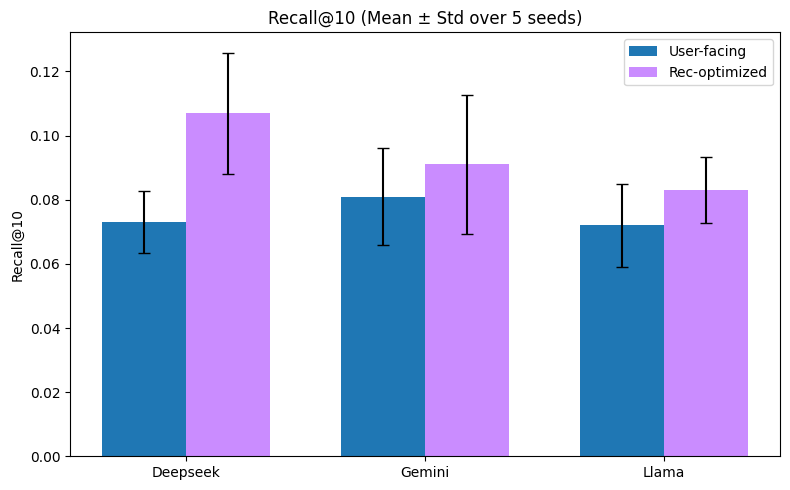

In [7]:
# 18
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PATH
# =========================
CSV_PATH = "/content/summary_mean_std_across_seeds.csv"

# =========================
# LOAD
# =========================
df = pd.read_csv(CSV_PATH)

# Make model names prettier
df["LLM"] = df["llm"].str.capitalize()
df["profile_type"] = df["profile_type"].replace({
    "user_facing": "User-facing",
    "rec_optimized": "Rec-optimized"
})

models = sorted(df["LLM"].astype(str).unique().tolist())

# =========================
# PREP DATA
# =========================
recall_user = []
recall_user_std = []
recall_rec = []
recall_rec_std = []

for m in models:
    user_row = df[(df["LLM"] == m) & (df["profile_type"] == "User-facing")].iloc[0]
    rec_row  = df[(df["LLM"] == m) & (df["profile_type"] == "Rec-optimized")].iloc[0]

    recall_user.append(user_row["recall10_mean"])
    recall_user_std.append(user_row["recall10_std"])

    recall_rec.append(rec_row["recall10_mean"])
    recall_rec_std.append(rec_row["recall10_std"])

# =========================
# PLOT
# =========================
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, recall_user, width,
        yerr=recall_user_std,
        capsize=4,
        label="User-facing")

plt.bar(x + width/2, recall_rec, width,
        yerr=recall_rec_std,
        capsize=4,
        label="Rec-optimized",
        color="#CA8CFF")

plt.xticks(x, models)
plt.ylabel("Recall@10")
plt.title("Recall@10 (Mean ± Std over 5 seeds)")
plt.legend()
plt.tight_layout()

plt.savefig("/content/recall_plot_from_csv.png", dpi=300)
plt.show()


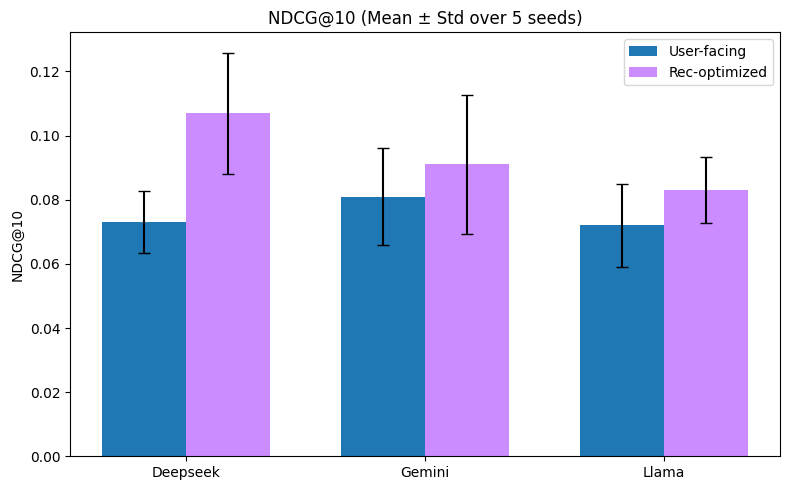

In [8]:
# 19
ndcg_user = []
ndcg_user_std = []
ndcg_rec = []
ndcg_rec_std = []

for m in models:
    user_row = df[(df["LLM"] == m) & (df["profile_type"] == "User-facing")].iloc[0]
    rec_row  = df[(df["LLM"] == m) & (df["profile_type"] == "Rec-optimized")].iloc[0]

    ndcg_user.append(user_row["ndcg10_mean"])
    ndcg_user_std.append(user_row["ndcg10_std"])

    ndcg_rec.append(rec_row["ndcg10_mean"])
    ndcg_rec_std.append(rec_row["ndcg10_std"])

# =========================
# PLOT
# =========================
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, recall_user, width,
        yerr=recall_user_std,
        capsize=4,
        label="User-facing")

plt.bar(x + width/2, recall_rec, width,
        yerr=recall_rec_std,
        capsize=4,
        label="Rec-optimized",
        color="#CA8CFF")

plt.xticks(x, models)
plt.ylabel("NDCG@10")
plt.title("NDCG@10 (Mean ± Std over 5 seeds)")
plt.legend()
plt.tight_layout()

plt.savefig("/content/NDCG10_plot_from_csv.png", dpi=300)
plt.show()



In [16]:
# 20
# It compares each model’s generated profiles (Gemini/LLaMA/DeepSeek) to the “evidence” top-15 tracks per (user_id, time_window_days) and
# measures how many explicit claims in the profile (artists, genres, countries, years) are unsupported by that user’s evidence.
# It outputs per-profile faithfulness metrics and summary tables (by model/profile_type/window) including unsupported-claim rate and a genre-token coverage score, then saves both CSVs.

import re
import pandas as pd
from collections import defaultdict

# =========================
# PATHS (edit as needed)
# =========================
PROFILES_CSVS = [
    ("/content/generated_profiles_gemini.csv", "gemini"),
    ("/content/generated_profiles_llama.csv",  "llama"),
    ("/content/generated_profiles_deepseek.csv", "deepseek"),
]

EVIDENCE_TOP15 = "/content/50_users_tracks_top15_enriched_.csv"

OUT_PER_PROFILE = "/content/biasA_faithfulness_per_profile.csv"
OUT_SUMMARY     = "/content/biasA_faithfulness_summary.csv"

# =========================
# Robust CSV load + helpers
# =========================
def read_csv_robust(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

def norm_str(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    return str(x).strip()

TOKEN_RE = re.compile(r"[a-z0-9]+", re.I)
YEAR_RE  = re.compile(r"\b(19|20)\d{2}\b")

def tokenize(text):
    return set(TOKEN_RE.findall(text.lower()))

def split_multi(x):
    """
    Split genre-like fields that can be:
    - comma separated
    - semicolon separated
    - pipe separated
    """
    s = norm_str(x).lower()
    if not s:
        return []
    s = s.replace("|", ",").replace(";", ",")
    parts = [p.strip() for p in s.split(",")]
    return [p for p in parts if p]

# =========================
# 1) Build evidence sets per (user_id, time_window_days)
# =========================
ev = read_csv_robust(EVIDENCE_TOP15)

# detect likely column names (adjust if yours differ)
def pick_col(cols, candidates):
    cols_l = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols_l:
            return cols_l[cand]
    # fallback: contains match
    for c in cols:
        cl = c.lower()
        for cand in candidates:
            if cand in cl:
                return c
    return None

col_user = pick_col(ev.columns, ["user_id", "userid", "user"])
col_tw   = pick_col(ev.columns, ["time_window_days", "timewindow_days", "window_days", "time_window"])
col_artist = pick_col(ev.columns, ["artist_name", "artist"])
col_track  = pick_col(ev.columns, ["track_name", "track", "title"])
col_country = pick_col(ev.columns, ["origin_country", "country", "artist_country"])
col_main_genre = pick_col(ev.columns, ["main_genre", "genre_main", "primary_genre", "genre"])
col_sec_genres = pick_col(ev.columns, ["secondary_genres", "secondary_genre", "genres_secondary", "subgenres"])
col_year  = pick_col(ev.columns, ["release_year", "year"])

required_ev = [col_user, col_tw, col_artist, col_track]
missing_ev = [name for name, col in [
    ("user_id", col_user),
    ("time_window_days", col_tw),
    ("artist_name", col_artist),
    ("track_name", col_track),
] if col is None]
if missing_ev:
    raise ValueError(f"Evidence file missing required columns: {missing_ev}. Found columns: {ev.columns.tolist()}")

# per-key evidence sets
evidence_genres    = defaultdict(set)
evidence_countries = defaultdict(set)
evidence_years     = defaultdict(set)
evidence_artists   = defaultdict(set)   # artist full names (lower)
evidence_artist_tokens = defaultdict(set)  # tokens from artist names
evidence_genre_tokens  = defaultdict(set)  # tokens from genre strings (for coverage)

# global vocabs (to detect what the profile is "claiming")
GLOBAL_GENRES = set()
GLOBAL_COUNTRIES = set()
GLOBAL_ARTISTS = set()

for _, r in ev.iterrows():
    uid = norm_str(r[col_user])
    twv = r[col_tw]
    if not uid or pd.isna(twv):
        continue
    key = (uid, int(twv))

    # genres
    g_main = split_multi(r[col_main_genre]) if col_main_genre else []
    g_sec  = split_multi(r[col_sec_genres]) if col_sec_genres else []
    g_all  = [g for g in (g_main + g_sec) if g]

    for g in g_all:
        evidence_genres[key].add(g)
        GLOBAL_GENRES.add(g)
        for t in tokenize(g):
            evidence_genre_tokens[key].add(t)

    # countries
    if col_country and pd.notna(r[col_country]):
        c = norm_str(r[col_country]).lower()
        if c:
            evidence_countries[key].add(c)
            GLOBAL_COUNTRIES.add(c)

    # years
    if col_year and pd.notna(r[col_year]):
        try:
            y = int(float(r[col_year]))
            if 1900 <= y <= 2026:
                evidence_years[key].add(y)
        except Exception:
            pass

    # artists
    a = norm_str(r[col_artist]).lower()
    if a:
        evidence_artists[key].add(a)
        GLOBAL_ARTISTS.add(a)
        evidence_artist_tokens[key] |= tokenize(a)

# Precompute sorted artist list for fast substring matching
GLOBAL_ARTISTS_LIST = sorted(GLOBAL_ARTISTS, key=len, reverse=True)

# =========================
# 2) Claim extraction from profile text
# =========================
def extract_claimed_years(text_lower):
    years = set()
    for m in YEAR_RE.findall(text_lower):
        # m returns only the prefix group ("19"/"20") due to grouping,
        # so we need finditer instead:
        pass
    years = set(int(x.group()) for x in re.finditer(r"\b(19|20)\d{2}\b", text_lower))
    return {y for y in years if 1900 <= y <= 2026}

def extract_claimed_countries(text_lower, token_set):
    """
    Countries can be multiword ("united states"). We match by substring
    against GLOBAL_COUNTRIES for better recall, but only for a small vocab.
    """
    claimed = set()
    for c in GLOBAL_COUNTRIES:
        if c and c in text_lower:
            claimed.add(c)
    # also catch single-token countries if your country field is like "us", "uk"
    # (already handled by substring)
    return claimed

def extract_claimed_genres(token_set):
    """
    Claim genres by token overlap with GLOBAL_GENRES tokens:
    We treat a genre as "claimed" if ALL its tokens appear in profile tokens.
    This avoids counting random single-token overlaps (e.g., 'rock').
    """
    claimed = set()
    for g in GLOBAL_GENRES:
        gtoks = tokenize(g)
        if not gtoks:
            continue
        if gtoks.issubset(token_set):
            claimed.add(g)
    return claimed

def extract_claimed_artists(text_lower):
    """
    Claim artists only if the full artist name appears as a substring.
    (Your evidence artist list is relatively small, so this is fine.)
    """
    claimed = set()
    for a in GLOBAL_ARTISTS_LIST:
        if a and a in text_lower:
            claimed.add(a)
    return claimed

# =========================
# 3) Score faithfulness per profile
# =========================
rows = []

for path, model_name in PROFILES_CSVS:
    df = read_csv_robust(path)

    # normalize schema
    if "profile_text" not in df.columns and "profile" in df.columns:
        df = df.rename(columns={"profile": "profile_text"})
    if "profile_type" not in df.columns and "type" in df.columns:
        df = df.rename(columns={"type": "profile_type"})

    req = ["user_id", "time_window_days", "profile_type", "profile_text"]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise ValueError(f"{path}: missing columns {miss}. Found: {df.columns.tolist()}")

    for _, r in df.iterrows():
        uid = norm_str(r["user_id"])
        tw  = r["time_window_days"]
        if not uid or pd.isna(tw):
            continue
        tw = int(tw)
        key = (uid, tw)
        if key not in evidence_artists:
            # no evidence for that user-window (e.g., dropped window)
            continue

        ptype = norm_str(r["profile_type"])
        text  = norm_str(r["profile_text"])
        text_lower = text.lower()
        toks = tokenize(text_lower)

        # what the profile "claims" (only from global vocab)
        claimed_genres    = extract_claimed_genres(toks)
        claimed_countries = extract_claimed_countries(text_lower, toks)
        claimed_years     = extract_claimed_years(text_lower)
        claimed_artists   = extract_claimed_artists(text_lower)

        # what is supported by evidence for this user-window
        ev_genres    = evidence_genres.get(key, set())
        ev_countries = evidence_countries.get(key, set())
        ev_years     = evidence_years.get(key, set())
        ev_artists   = evidence_artists.get(key, set())

        # unsupported = claimed but not in evidence
        unsupported_genres    = claimed_genres - ev_genres
        unsupported_countries = claimed_countries - ev_countries
        unsupported_years     = claimed_years - ev_years
        unsupported_artists   = claimed_artists - ev_artists

        # counts
        total_claims = (
            len(claimed_genres) +
            len(claimed_countries) +
            len(claimed_years) +
            len(claimed_artists)
        )
        unsupported_claims = (
            len(unsupported_genres) +
            len(unsupported_countries) +
            len(unsupported_years) +
            len(unsupported_artists)
        )
        unsupported_rate = (unsupported_claims / total_claims) if total_claims > 0 else 0.0

        # diversity retention proxy: how much of evidence genre tokens appear in profile
        ev_genre_tok = evidence_genre_tokens.get(key, set())
        covered_genre_tok = len(ev_genre_tok & toks)
        genre_token_coverage = (covered_genre_tok / len(ev_genre_tok)) if len(ev_genre_tok) > 0 else 0.0

        rows.append({
            "model": model_name,
            "user_id": uid,
            "time_window_days": tw,
            "profile_type": ptype,

            "total_claims": total_claims,
            "unsupported_claims": unsupported_claims,
            "unsupported_claim_rate": unsupported_rate,

            "claimed_genres": len(claimed_genres),
            "unsupported_genres": len(unsupported_genres),

            "claimed_countries": len(claimed_countries),
            "unsupported_countries": len(unsupported_countries),

            "claimed_years": len(claimed_years),
            "unsupported_years": len(unsupported_years),

            "claimed_artists": len(claimed_artists),
            "unsupported_artists": len(unsupported_artists),

            "genre_token_coverage": genre_token_coverage,
        })

out = pd.DataFrame(rows)
out.to_csv(OUT_PER_PROFILE, index=False)
print("Saved per-profile faithfulness metrics:", OUT_PER_PROFILE, "| rows:", len(out))

# =========================
# 4) Summary tables
# =========================
summary = (
    out.groupby(["model", "profile_type", "time_window_days"])
       .agg(
           mean_unsupported_rate=("unsupported_claim_rate", "mean"),
           mean_genre_token_coverage=("genre_token_coverage", "mean"),
           mean_total_claims=("total_claims", "mean"),
           n_profiles=("user_id", "count"),
       )
       .reset_index()
)
summary.to_csv(OUT_SUMMARY, index=False)
print("Saved summary:", OUT_SUMMARY)

# quick overall (collapsed across windows)
overall = (
    out.groupby(["model", "profile_type"])
       .agg(
           mean_unsupported_rate=("unsupported_claim_rate", "mean"),
           mean_genre_token_coverage=("genre_token_coverage", "mean"),
           mean_total_claims=("total_claims", "mean"),
           n_profiles=("user_id", "count"),
       )
       .reset_index()
)
print("\nOverall (all windows):")
print(overall.to_string(index=False))


Saved per-profile faithfulness metrics: /content/biasA_faithfulness_per_profile.csv | rows: 1200
Saved summary: /content/biasA_faithfulness_summary.csv

Overall (all windows):
   model  profile_type  mean_unsupported_rate  mean_genre_token_coverage  mean_total_claims  n_profiles
deepseek rec_optimized               0.262102                   0.665904             35.115         200
deepseek   user_facing               0.216966                   0.245039             11.730         200
  gemini rec_optimized               0.198528                   0.574092             32.155         200
  gemini   user_facing               0.216042                   0.264815             13.515         200
   llama rec_optimized               0.271354                   0.329647             16.500         200
   llama   user_facing               0.280917                   0.188052              9.930         200
